In [1]:
# Custom utilities
import NO_utilities

# Standard libraries
import gc
import hashlib
import json
import os
import random
import sys
import time
from datetime import datetime
from pathlib import Path

# Scientific computing
import numpy as np
import scipy as sp

# Deep learning - PyTorch
import torch
import torch.fft
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import (
    ConcatDataset,
    DataLoader,
    Dataset,
    TensorDataset,
    random_split,
)

# Neural operator specific
from neuralop import H1Loss, LpLoss, Trainer
from neuralop.models import FNO, FNO2d, TFNO, TFNO2d

# Data processing and visualization
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torchvision import transforms

In [2]:
# Force garbage collection to release file handles
gc.collect()

228

## Load data

In [ ]:
# Repo naming (see DATA_GENERATION.md):
#   wavevector coords     -> wavevectors_full.pt
#   wavevector input img  -> waveforms_full.pt      (per wavevector index)
#   band input img        -> band_fft_full.pt       (per band index)
#   eigenvalue (scalar)   -> eigenvalue_data_full.pt
#   eigenvalue (encoded)  -> eigenfrequency_uniform_full.pt / eigenfrequency_fft_full.pt
#   eigenvector (4 ch)    -> displacements_dataset.pt (x_real, x_imag, y_real, y_imag)

n = 10
LOAD_GEOM_SEED = 0

c_test_pt = Path(r"D:\Research\NO-2D-Metamaterials\DATASETS\c_test\continuous_2026-03-05_20-07-34_pt")
b_test_pt = Path(r"D:\Research\NO-2D-Metamaterials\DATASETS\b_test\binarized_2026-03-08_16-34-27_pt")


def combined_index(d: int, w: int, b: int, n_wv: int, n_band: int) -> int:
    return int(d) * n_wv * n_band + int(w) * n_band + int(b)


# --- c_test (continuous) ---
_c_geometries_full = torch.load(c_test_pt / "geometries_full.pt", weights_only=False)
_g = torch.Generator().manual_seed(LOAD_GEOM_SEED)
c_test_geom_idx = torch.randperm(_c_geometries_full.shape[0], generator=_g)[:n].sort().values
c_test_geometries = _c_geometries_full[c_test_geom_idx]
del _c_geometries_full

c_test_wavevectors = torch.load(c_test_pt / "wavevectors_full.pt", weights_only=False)[c_test_geom_idx]
c_test_waveforms = torch.load(c_test_pt / "waveforms_full.pt", weights_only=False)
c_test_band_ffts = torch.load(c_test_pt / "band_fft_full.pt", weights_only=False)
c_test_eigenvalue_data = torch.load(c_test_pt / "eigenvalue_data_full.pt", weights_only=False)[c_test_geom_idx]
c_test_eigenfrequency_uniform = torch.load(c_test_pt / "eigenfrequency_uniform_full.pt", weights_only=False)[c_test_geom_idx]
c_test_eigenfrequency_fft = torch.load(c_test_pt / "eigenfrequency_fft_full.pt", weights_only=False)[c_test_geom_idx]
c_test_n_wv = int(c_test_waveforms.shape[0])
c_test_n_band = int(c_test_band_ffts.shape[0])
_disp_c = torch.load(c_test_pt / "displacements_dataset.pt", weights_only=False)
c_test_disp_rows, c_test_disp_flat_map = [], {}
for d in c_test_geom_idx.tolist():
    d = int(d)
    for w in range(c_test_n_wv):
        for b in range(c_test_n_band):
            flat = combined_index(d, w, b, c_test_n_wv, c_test_n_band)
            c_test_disp_flat_map[flat] = len(c_test_disp_rows)
            c_test_disp_rows.append(flat)
c_test_disp_rows = torch.as_tensor(c_test_disp_rows, dtype=torch.long)
c_test_displacements = TensorDataset(*[_disp_c.tensors[i][c_test_disp_rows] for i in range(4)])
del _disp_c


def c_test_stack_target_channels(d: int, w: int, b: int) -> torch.Tensor:
    ld = int((c_test_geom_idx == d).nonzero(as_tuple=True)[0].item())
    ch0 = c_test_eigenfrequency_uniform[ld, w, b]
    row = c_test_disp_flat_map[combined_index(d, w, b, c_test_n_wv, c_test_n_band)]
    chans = [c_test_displacements.tensors[i][row] for i in range(4)]
    return torch.stack([ch0, *chans], dim=0)


print(f"c_test: {c_test_pt}")
print(f"  geom_idx {c_test_geom_idx.tolist()}")
print(f"  geometries {c_test_geometries.shape}, wavevectors {c_test_wavevectors.shape}")
print(f"  waveforms {c_test_waveforms.shape}, band_ffts {c_test_band_ffts.shape}")
print(f"  eigenvalue_data {c_test_eigenvalue_data.shape}, displacement rows {c_test_displacements.tensors[0].shape[0]}")

# --- b_test (binary) ---
_b_geometries_full = torch.load(b_test_pt / "geometries_full.pt", weights_only=False)
_g = torch.Generator().manual_seed(LOAD_GEOM_SEED + 1)
b_test_geom_idx = torch.randperm(_b_geometries_full.shape[0], generator=_g)[:n].sort().values
b_test_geometries = _b_geometries_full[b_test_geom_idx]
del _b_geometries_full

b_test_wavevectors = torch.load(b_test_pt / "wavevectors_full.pt", weights_only=False)[b_test_geom_idx]
b_test_waveforms = torch.load(b_test_pt / "waveforms_full.pt", weights_only=False)
b_test_band_ffts = torch.load(b_test_pt / "band_fft_full.pt", weights_only=False)
b_test_eigenvalue_data = torch.load(b_test_pt / "eigenvalue_data_full.pt", weights_only=False)[b_test_geom_idx]
b_test_eigenfrequency_uniform = torch.load(b_test_pt / "eigenfrequency_uniform_full.pt", weights_only=False)[b_test_geom_idx]
b_test_eigenfrequency_fft = torch.load(b_test_pt / "eigenfrequency_fft_full.pt", weights_only=False)[b_test_geom_idx]
b_test_n_wv = int(b_test_waveforms.shape[0])
b_test_n_band = int(b_test_band_ffts.shape[0])
_disp_b = torch.load(b_test_pt / "displacements_dataset.pt", weights_only=False)
b_test_disp_rows, b_test_disp_flat_map = [], {}
for d in b_test_geom_idx.tolist():
    d = int(d)
    for w in range(b_test_n_wv):
        for b in range(b_test_n_band):
            flat = combined_index(d, w, b, b_test_n_wv, b_test_n_band)
            b_test_disp_flat_map[flat] = len(b_test_disp_rows)
            b_test_disp_rows.append(flat)
b_test_disp_rows = torch.as_tensor(b_test_disp_rows, dtype=torch.long)
b_test_displacements = TensorDataset(*[_disp_b.tensors[i][b_test_disp_rows] for i in range(4)])
del _disp_b


def b_test_stack_target_channels(d: int, w: int, b: int) -> torch.Tensor:
    ld = int((b_test_geom_idx == d).nonzero(as_tuple=True)[0].item())
    ch0 = b_test_eigenfrequency_uniform[ld, w, b]
    row = b_test_disp_flat_map[combined_index(d, w, b, b_test_n_wv, b_test_n_band)]
    chans = [b_test_displacements.tensors[i][row] for i in range(4)]
    return torch.stack([ch0, *chans], dim=0)


print(f"b_test: {b_test_pt}")
print(f"  geom_idx {b_test_geom_idx.tolist()}")
print(f"  geometries {b_test_geometries.shape}, wavevectors {b_test_wavevectors.shape}")
print(f"  waveforms {b_test_waveforms.shape}, band_ffts {b_test_band_ffts.shape}")
print(f"  eigenvalue_data {b_test_eigenvalue_data.shape}, displacement rows {b_test_displacements.tensors[0].shape[0]}")

c_test: D:\Research\NO-2D-Metamaterials\DATASETS\c_test\continuous_2026-03-05_20-07-34_pt
  geom_idx [37, 44, 209, 264, 500, 561, 675, 719, 775, 947]
  geometries torch.Size([10, 32, 32]), wavevectors torch.Size([10, 325, 2])
  waveforms torch.Size([325, 32, 32]), band_ffts torch.Size([6, 32, 32])
  eigenvalue_data torch.Size([10, 325, 6]), displacement rows 19500
b_test: D:\Research\NO-2D-Metamaterials\DATASETS\b_test\binarized_2026-03-08_16-34-27_pt
  geom_idx [66, 239, 268, 303, 436, 573, 593, 845, 919, 999]
  geometries torch.Size([10, 32, 32]), wavevectors torch.Size([10, 325, 2])
  waveforms torch.Size([325, 32, 32]), band_ffts torch.Size([6, 32, 32])
  eigenvalue_data torch.Size([10, 325, 6]), displacement rows 19500


In [20]:
SAMPLE_SEED = 2
rng = np.random.default_rng(SAMPLE_SEED)

_c_ridx = torch.load(c_test_pt / "reduced_indices.pt", weights_only=False)
if isinstance(_c_ridx, list):
    _c_ridx = torch.tensor(_c_ridx, dtype=torch.long)
_c_rows = torch.isin(_c_ridx[:, 0], c_test_geom_idx).nonzero(as_tuple=True)[0]
c_test_row = int(_c_rows[int(rng.integers(0, len(_c_rows)))])
c_test_g, c_test_w, c_test_b = (int(x) for x in _c_ridx[c_test_row].tolist())
c_test_combined = combined_index(c_test_g, c_test_w, c_test_b, c_test_n_wv, c_test_n_band)

rng = np.random.default_rng(SAMPLE_SEED + 1)
_b_ridx = torch.load(b_test_pt / "reduced_indices.pt", weights_only=False)
if isinstance(_b_ridx, list):
    _b_ridx = torch.tensor(_b_ridx, dtype=torch.long)
_b_rows = torch.isin(_b_ridx[:, 0], b_test_geom_idx).nonzero(as_tuple=True)[0]
b_test_row = int(_b_rows[int(rng.integers(0, len(_b_rows)))])
b_test_g, b_test_w, b_test_b = (int(x) for x in _b_ridx[b_test_row].tolist())
b_test_combined = combined_index(b_test_g, b_test_w, b_test_b, b_test_n_wv, b_test_n_band)

print("c_test sample")
print(f"  g={c_test_g}, w={c_test_w}, b={c_test_b}, combined_index={c_test_combined}, inputs_row={c_test_row}")
print("b_test sample")
print(f"  g={b_test_g}, w={b_test_w}, b={b_test_b}, combined_index={b_test_combined}, inputs_row={b_test_row}")

c_test sample
  g=775, w=74, b=2, combined_index=1511696, inputs_row=302396
b_test sample
  g=919, w=245, b=0, combined_index=1793520, inputs_row=358454


### Generate geometry examples

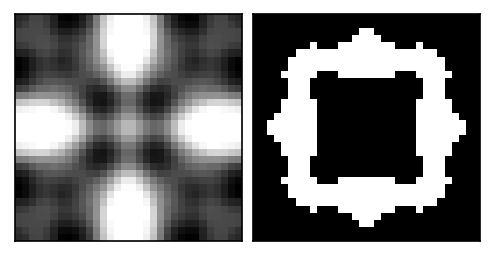

In [21]:
c_geom = c_test_geometries[int((c_test_geom_idx == c_test_g).nonzero(as_tuple=True)[0].item())].float().cpu().numpy()
b_geom = b_test_geometries[int((b_test_geom_idx == b_test_g).nonzero(as_tuple=True)[0].item())].float().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=150)
for ax, geom in zip(axes, (c_geom, b_geom)):
    ax.imshow(geom, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.subplots_adjust(wspace=0.05)
plt.show()

### Generate encoded inputs example

c_test combined=1511696, row=302396: input torch.Size([3, 32, 32]), output torch.Size([5, 32, 32])
b_test combined=1793520, row=358454: input torch.Size([3, 32, 32]), output torch.Size([5, 32, 32])


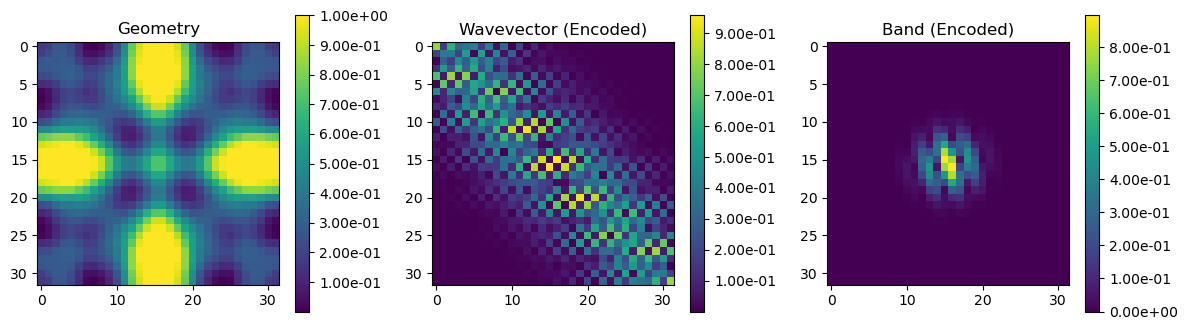

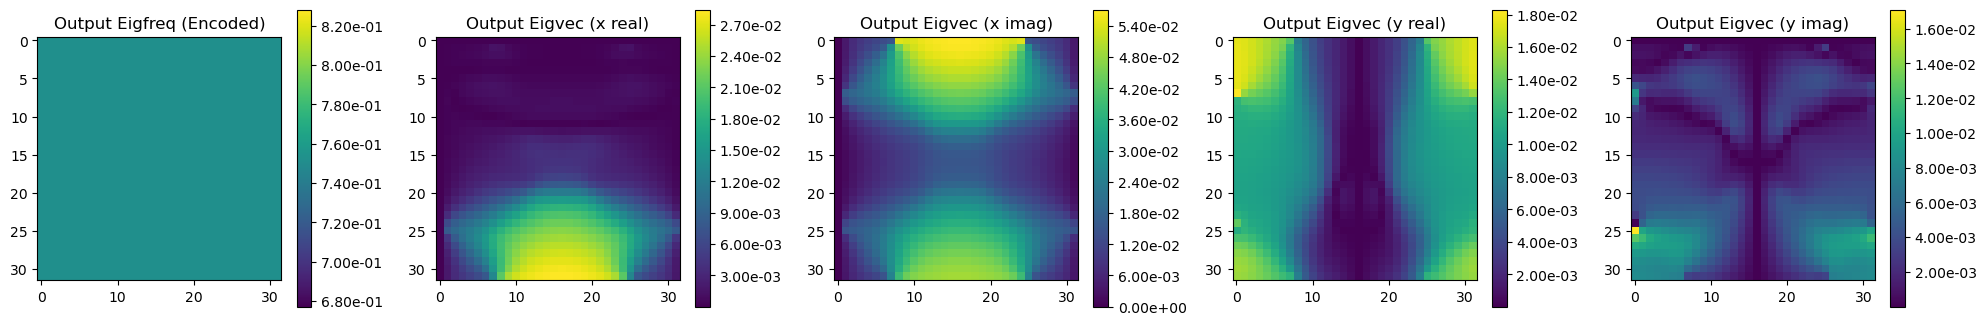

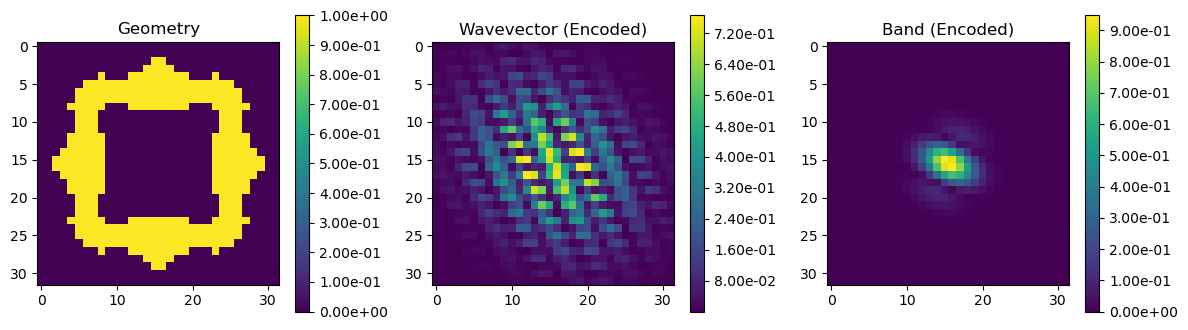

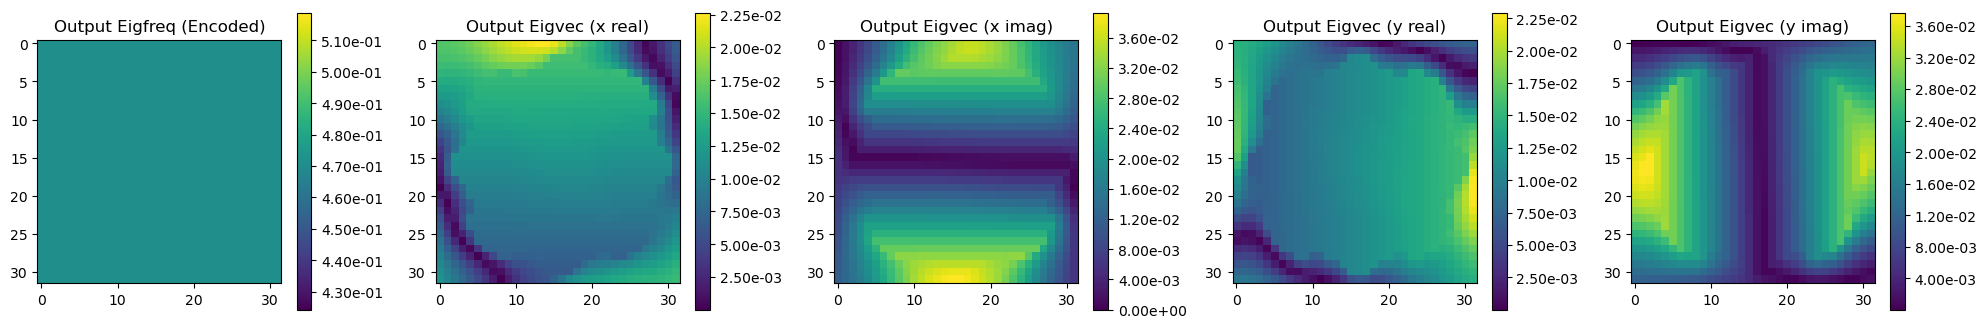

In [23]:
_c_inputs = torch.load(c_test_pt / "inputs.pt", map_location="cpu", mmap=True, weights_only=True)
_c_outputs = torch.load(c_test_pt / "outputs_w_uniform.pt", map_location="cpu", mmap=True, weights_only=True)
c_test_input = _c_inputs[c_test_row].float()
c_test_output = _c_outputs[c_test_row].float()

_b_inputs = torch.load(b_test_pt / "inputs.pt", map_location="cpu", mmap=True, weights_only=True)
_b_outputs = torch.load(b_test_pt / "outputs_w_uniform.pt", map_location="cpu", mmap=True, weights_only=True)
b_test_input = _b_inputs[b_test_row].float()
b_test_output = _b_outputs[b_test_row].float()

print(f"c_test combined={c_test_combined}, row={c_test_row}: input {c_test_input.shape}, output {c_test_output.shape}")
print(f"b_test combined={b_test_combined}, row={b_test_row}: input {b_test_input.shape}, output {b_test_output.shape}")

NO_utilities.visualize_sample(
    c_test_input.cpu(),
    c_test_output.cpu(),
    None,
    field_cmap="RdBu_r",
    diverge_center=0.0,
)
NO_utilities.visualize_sample(
    b_test_input.cpu(),
    b_test_output.cpu(),
    None,
    field_cmap="RdBu_r",
    diverge_center=0.0,
)

## Model evaluation

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using Device:', device)
print("Using PyTorch version:", torch.__version__)

Using Device: cuda
Using PyTorch version: 2.5.1


In [18]:
load_path = Path(
    # r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260323_20260323_122907_19312\NO_I3O5_BCF16_L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260323_best_fno2d_compat.pth"
    # r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_best_fno2d_compat.pth"
    r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_E30.pth"
)
run_dir = load_path.parent

with open(run_dir / "resolved_config.json", "r", encoding="utf-8") as f:
    cfg = json.load(f)
params = cfg["params"]

model = FNO2d(
    in_channels=int(params["in_channels"]),
    out_channels=int(params["out_channels"]),
    n_modes_height=int(params["modes_height"]),
    n_modes_width=int(params["modes_width"]),
    hidden_channels=int(params["hidden_channels"]),
    n_layers=int(params["layers"]),
).to(device)

if load_path.is_file():
    try:
        state_dict = torch.load(load_path, map_location=device)
        if isinstance(state_dict, dict):
            state_dict = {k: v for k, v in state_dict.items() if not k.startswith("_")}
        model.load_state_dict(state_dict)
        print(f"Loaded converted unwrapped model from {load_path}")
        # print(
        #     f"Model config: in={params['in_channels']}, out={params['out_channels']}, "
        #     f"modes=({params['modes_height']},{params['modes_width']}), hidden={params['hidden_channels']}, layers={params['layers']}"
        # )
    except Exception as e:
        print(f"Error loading converted model: {e}")
        print("Model will start with random weights")
else:
    print(f"Missing converted checkpoint: {load_path}")

model.eval()


Loaded converted unwrapped model from D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_E30.pth


C:\Users\hz283\AppData\Local\Temp\ipykernel_32356\1663733497.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=device)


FNO2d(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([128, 128, 32, 17]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
          (1): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 5

Sample 0: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.5747
Output max: 0.0694, min: -0.0366
Target max: 0.0688, min: -0.0343
Target scale (max - min): 0.1032
Average absolute error per pixel (output vs target): 0.000700


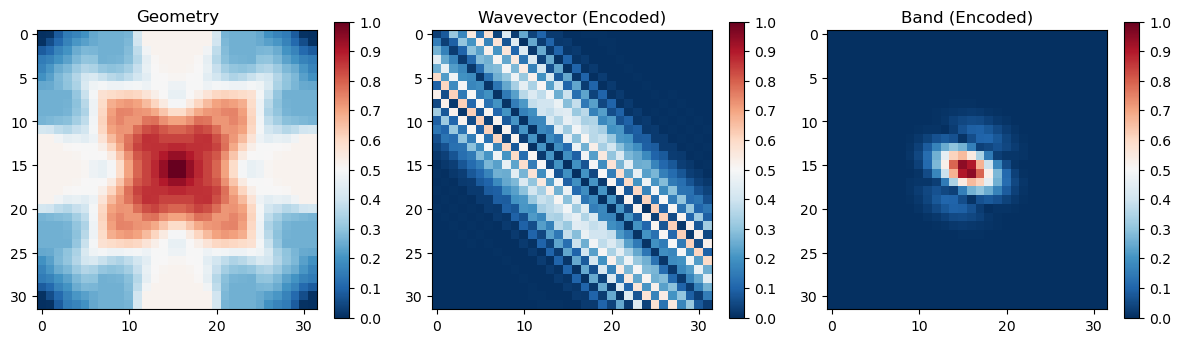

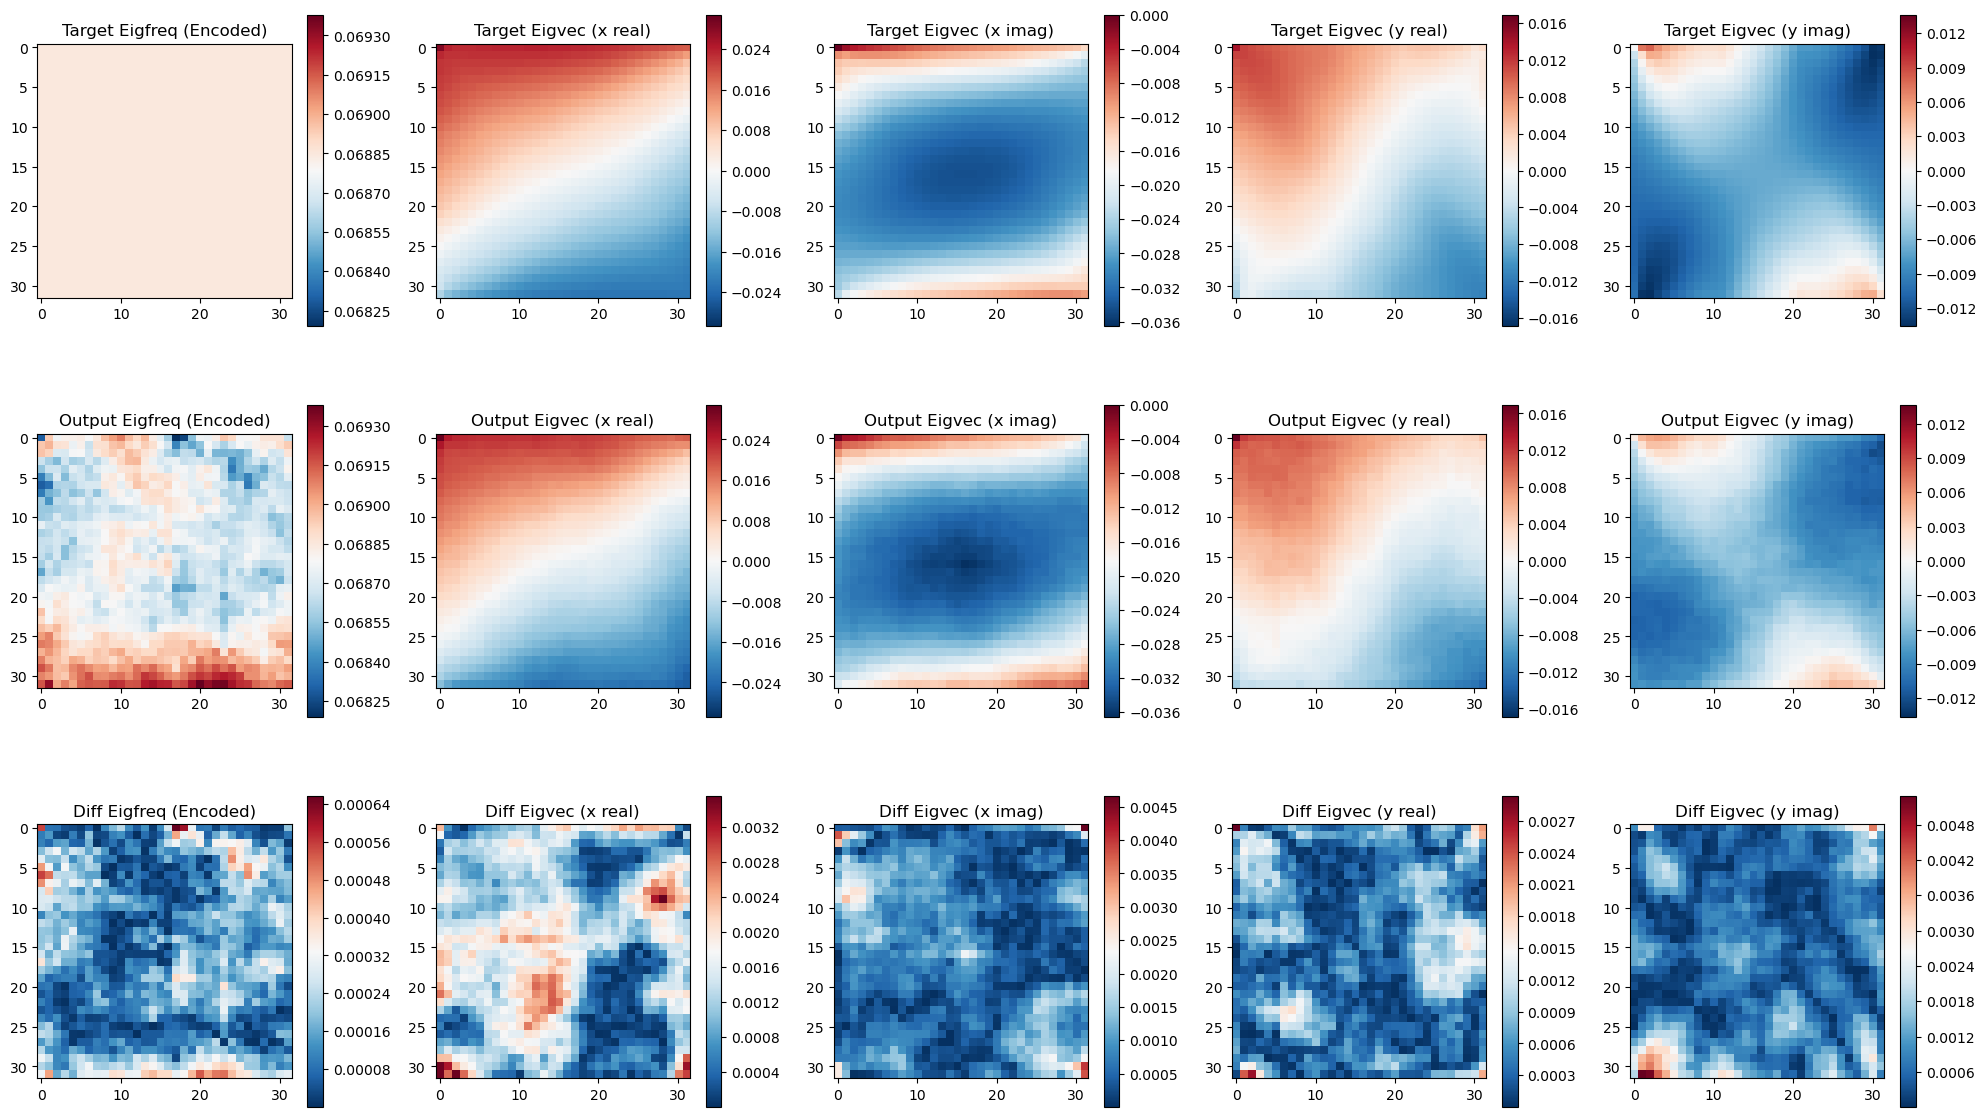

Sample 1: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.7949
Output max: 0.3854, min: -0.2569
Target max: 0.3879, min: -0.2773
Target scale (max - min): 0.6653
Average absolute error per pixel (output vs target): 0.000540


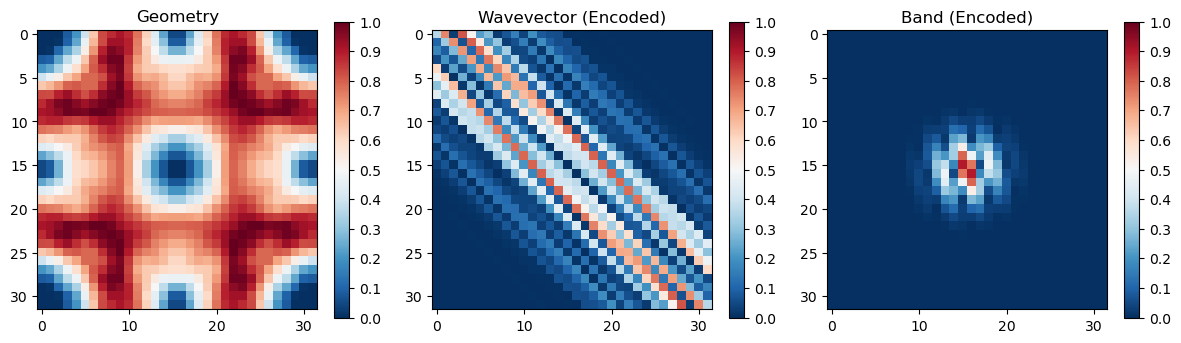

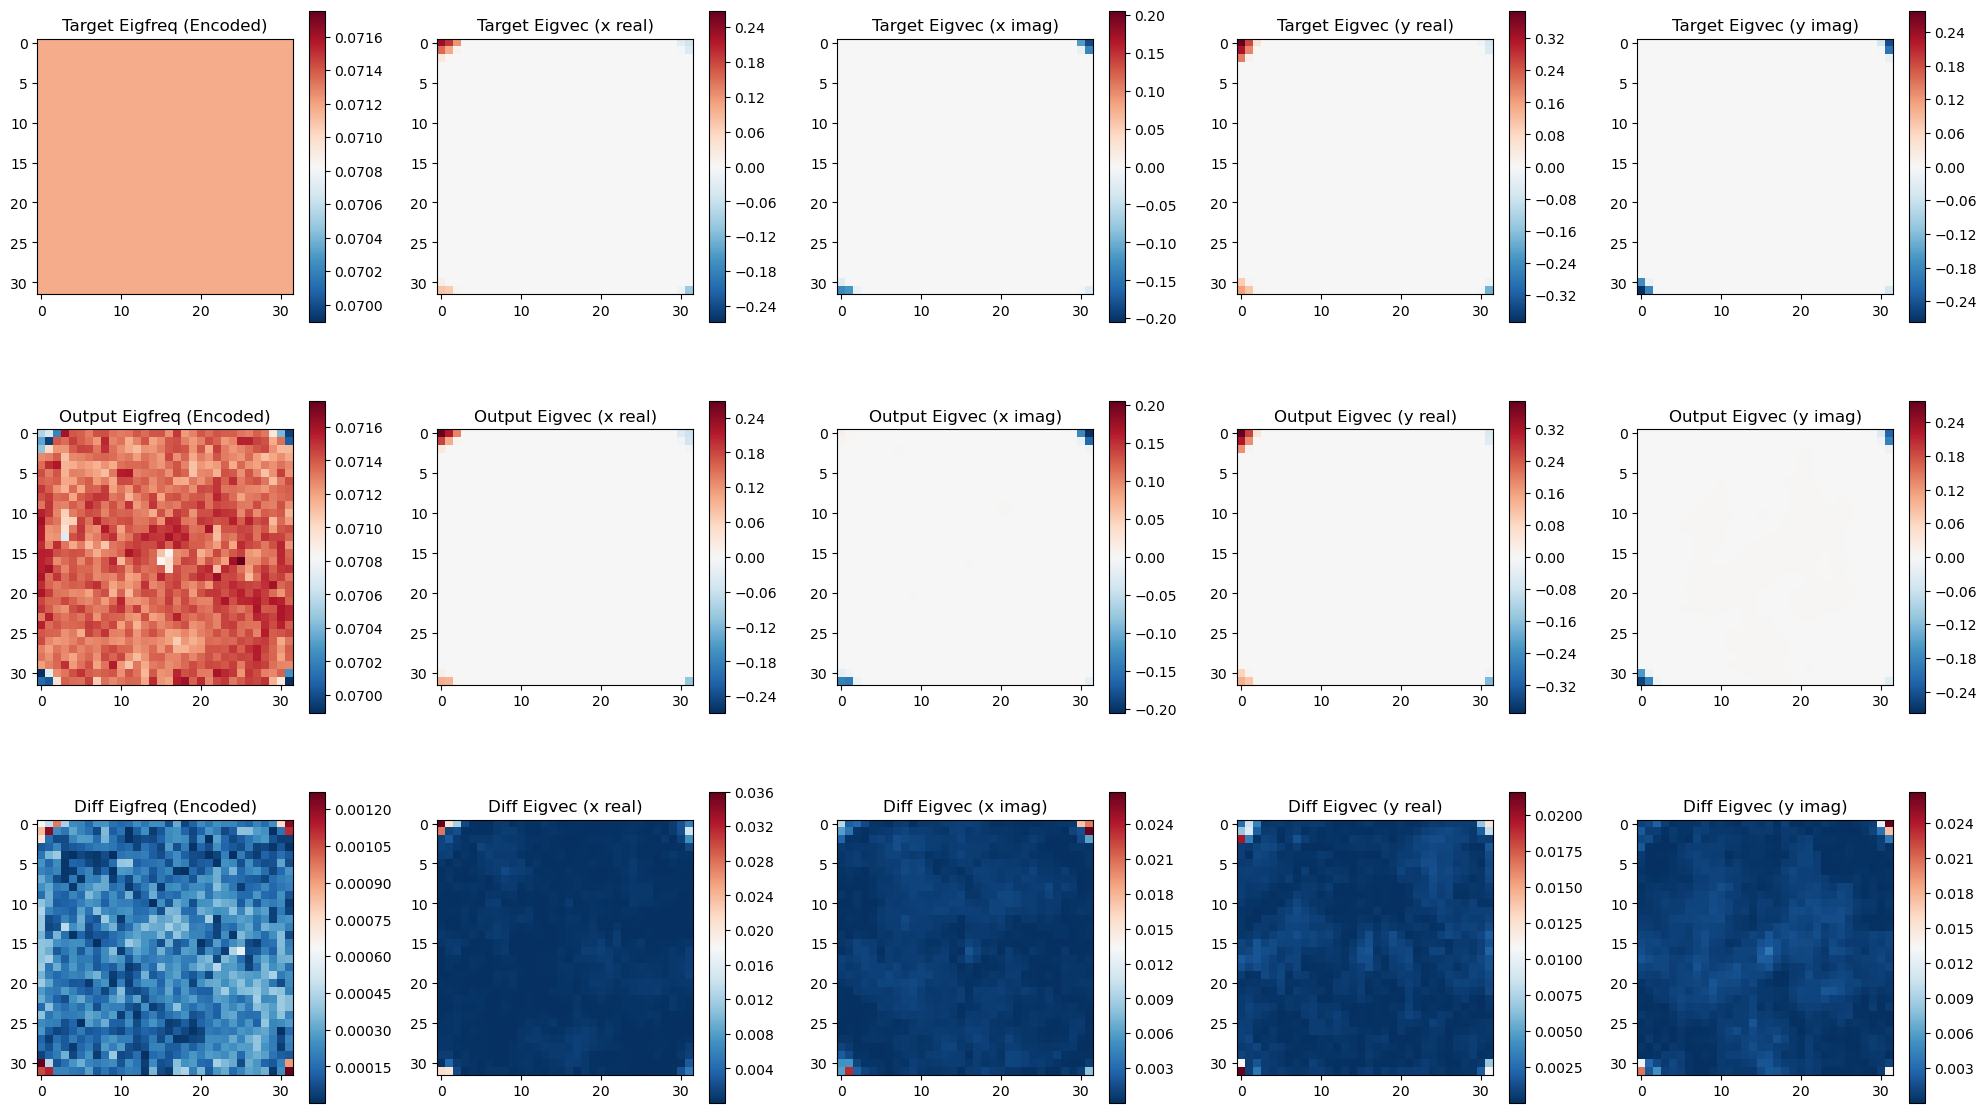

Sample 2: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.9131
Output max: 0.1222, min: -0.1535
Target max: 0.1312, min: -0.1544
Target scale (max - min): 0.2856
Average absolute error per pixel (output vs target): 0.000964


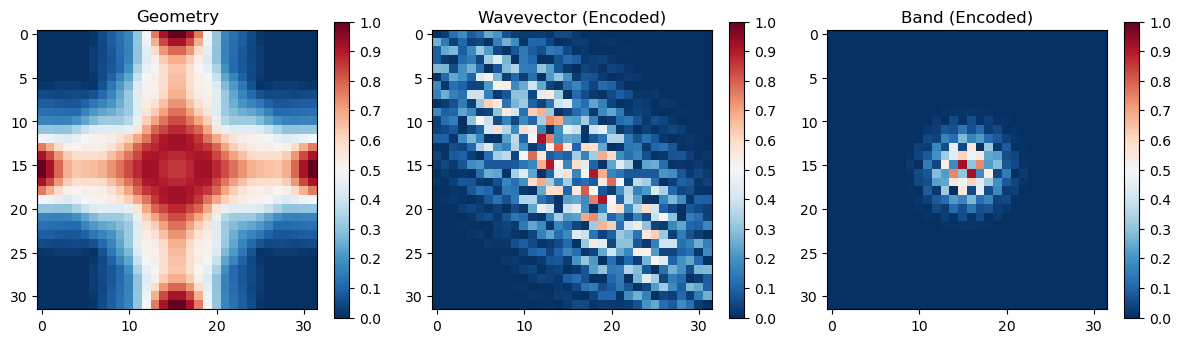

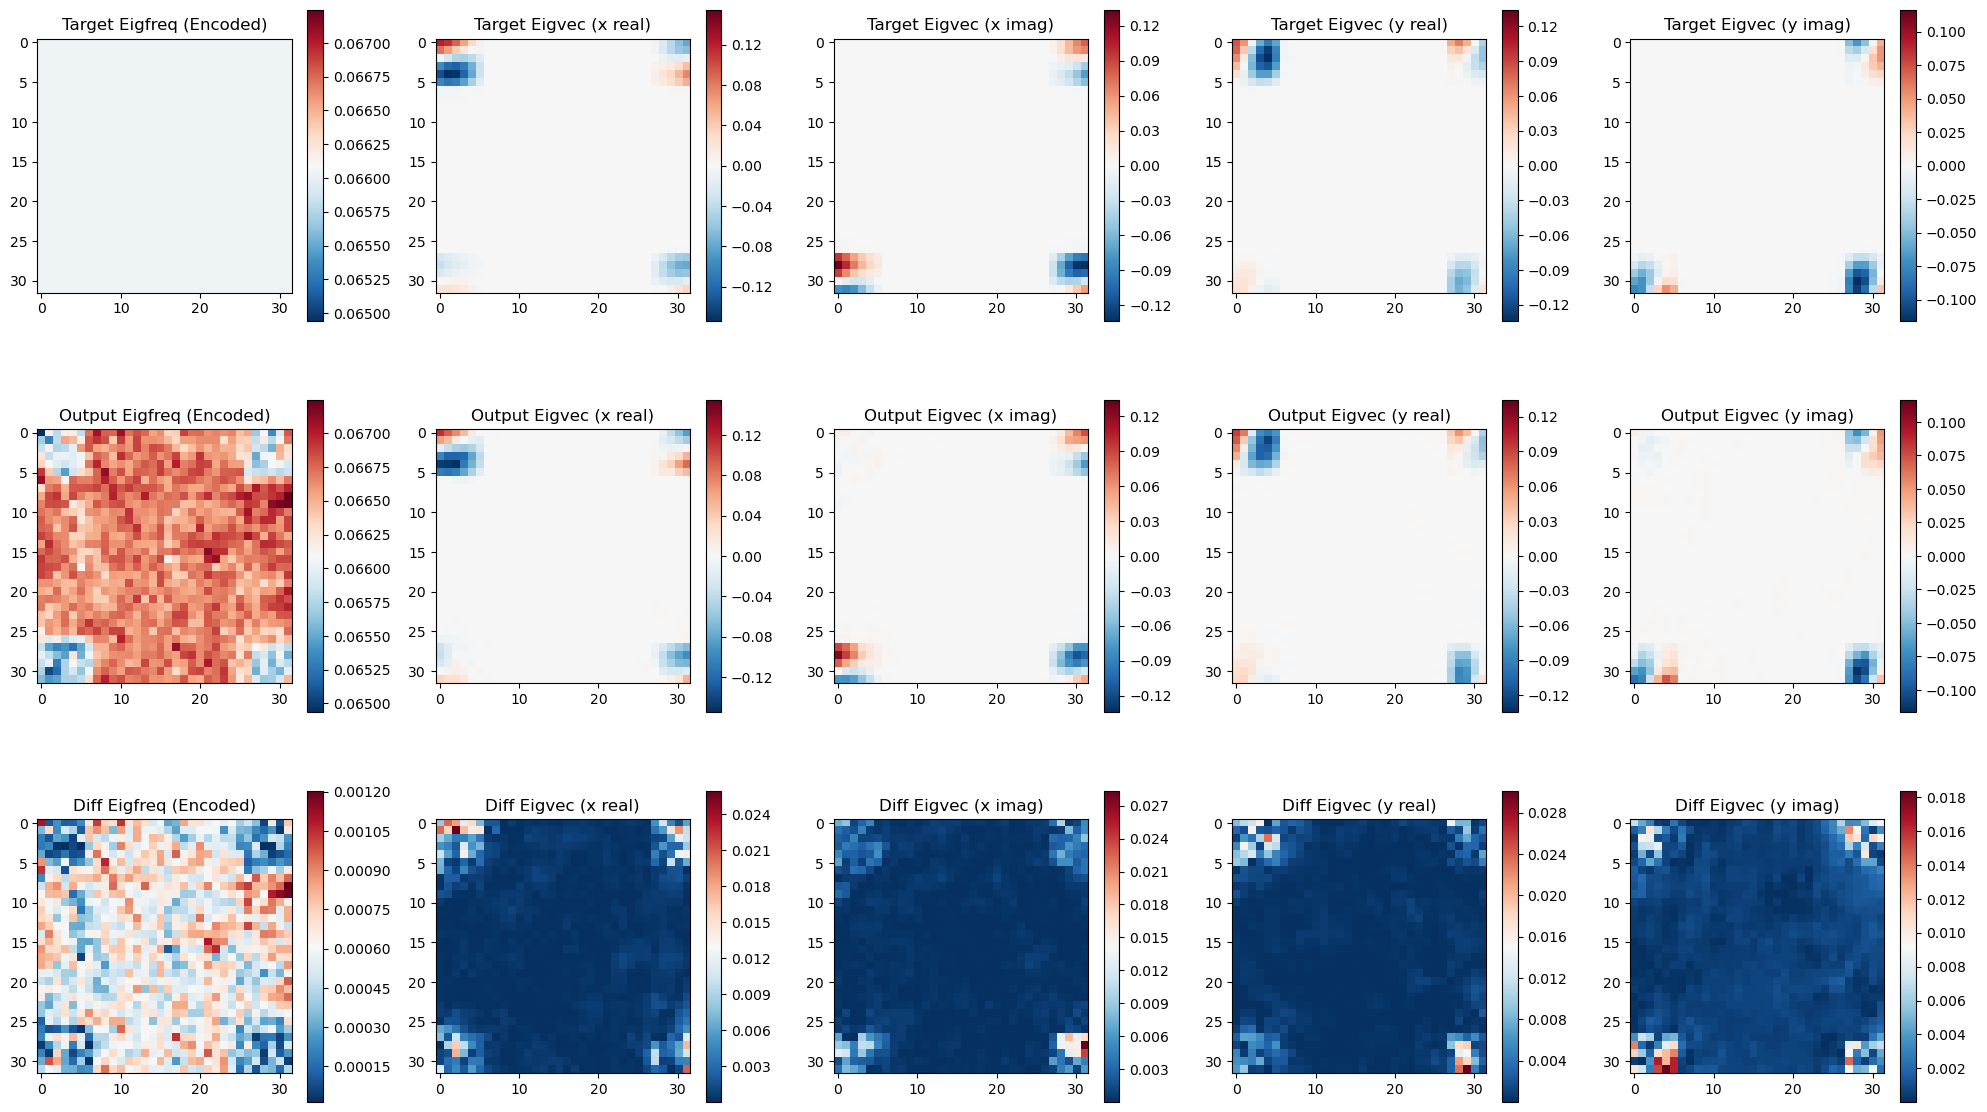

Sample 3: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.9839
Output max: 0.0788, min: -0.0291
Target max: 0.0813, min: -0.0291
Target scale (max - min): 0.1104
Average absolute error per pixel (output vs target): 0.001668


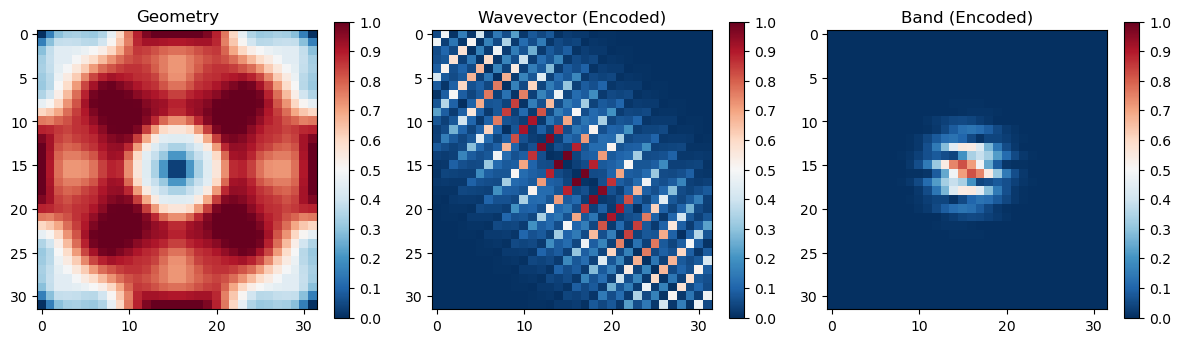

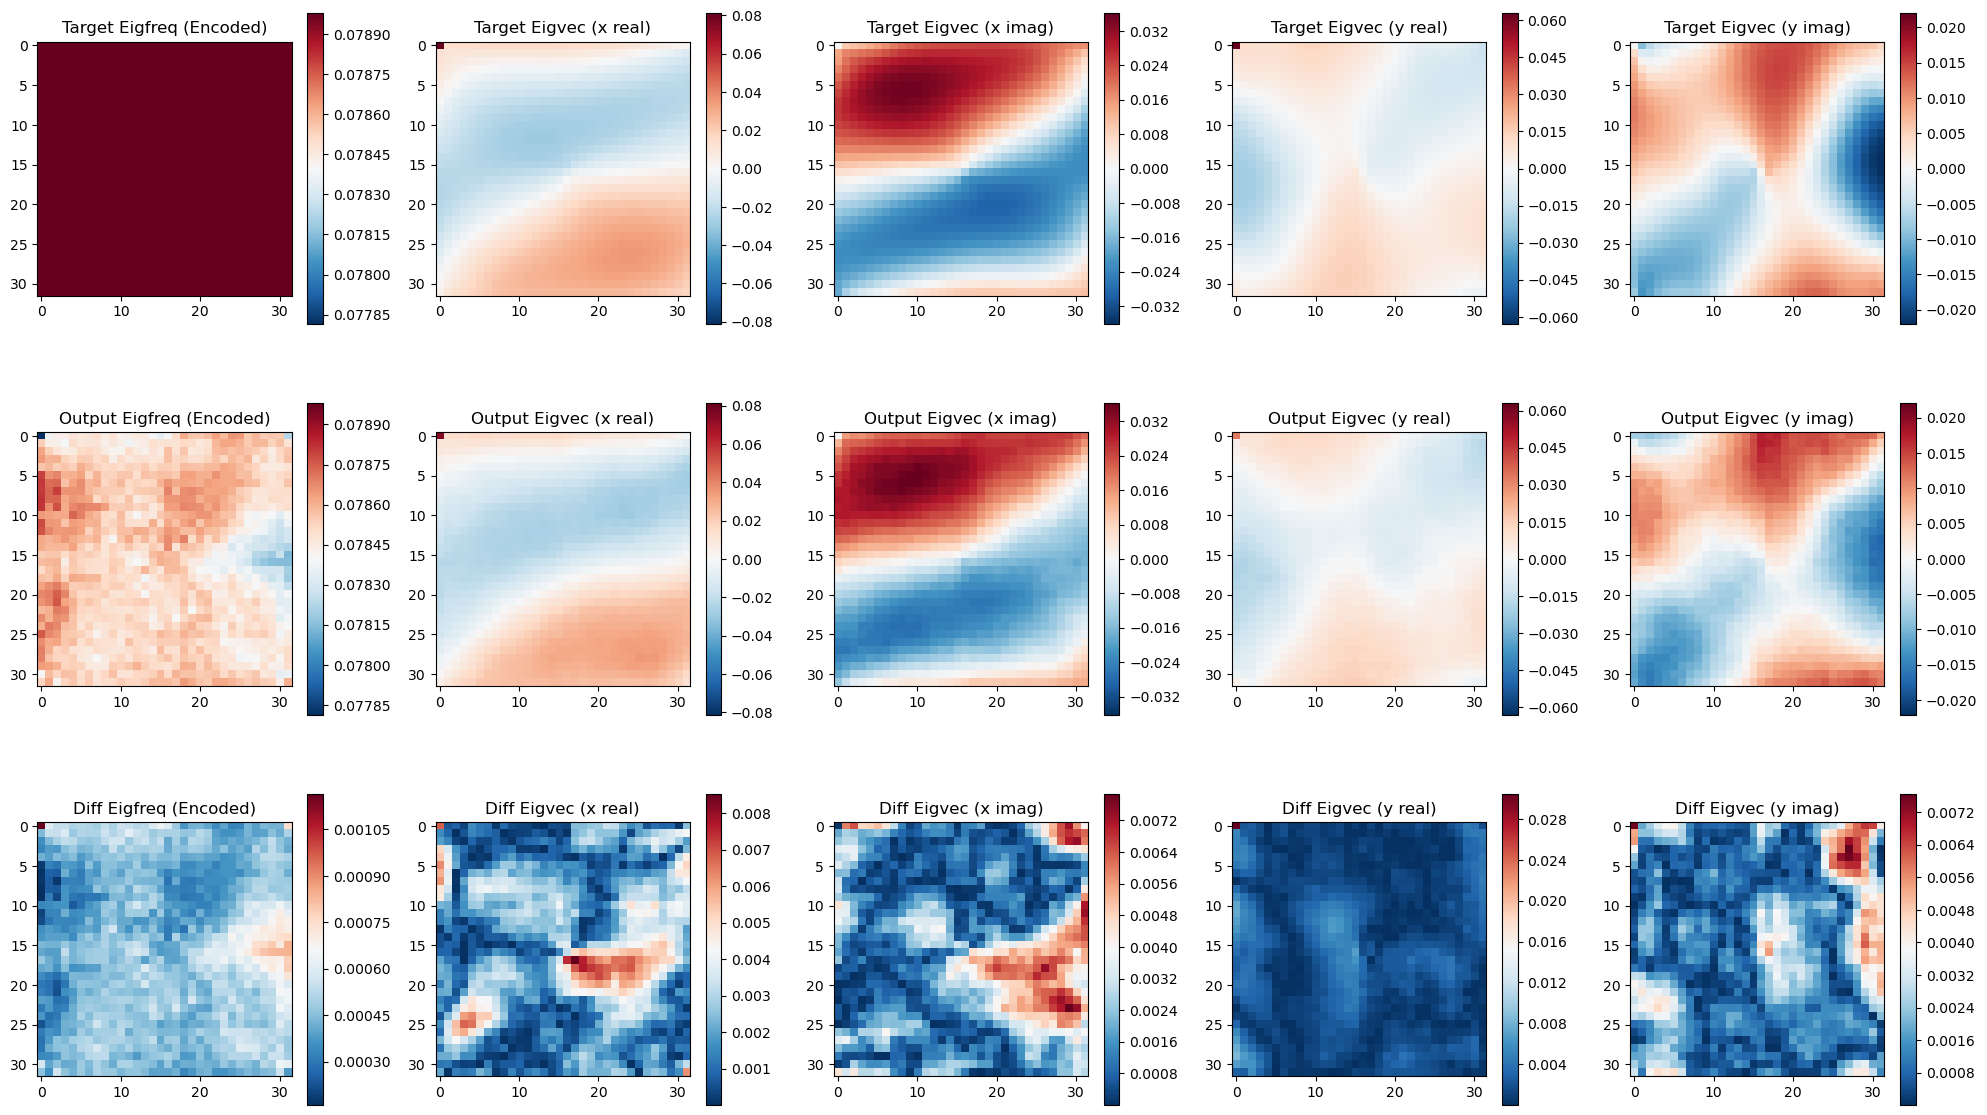

Sample 4: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.7769
Output max: 0.6713, min: -0.0210
Target max: 0.6377, min: -0.0133
Target scale (max - min): 0.6510
Average absolute error per pixel (output vs target): 0.001419


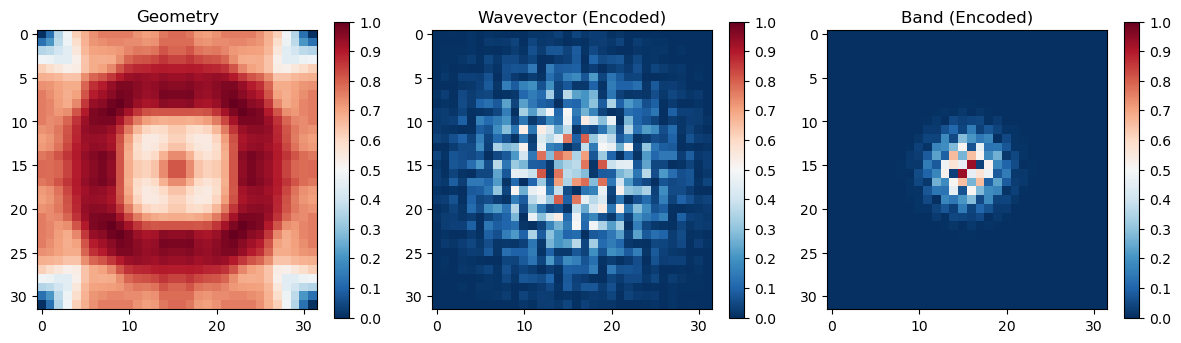

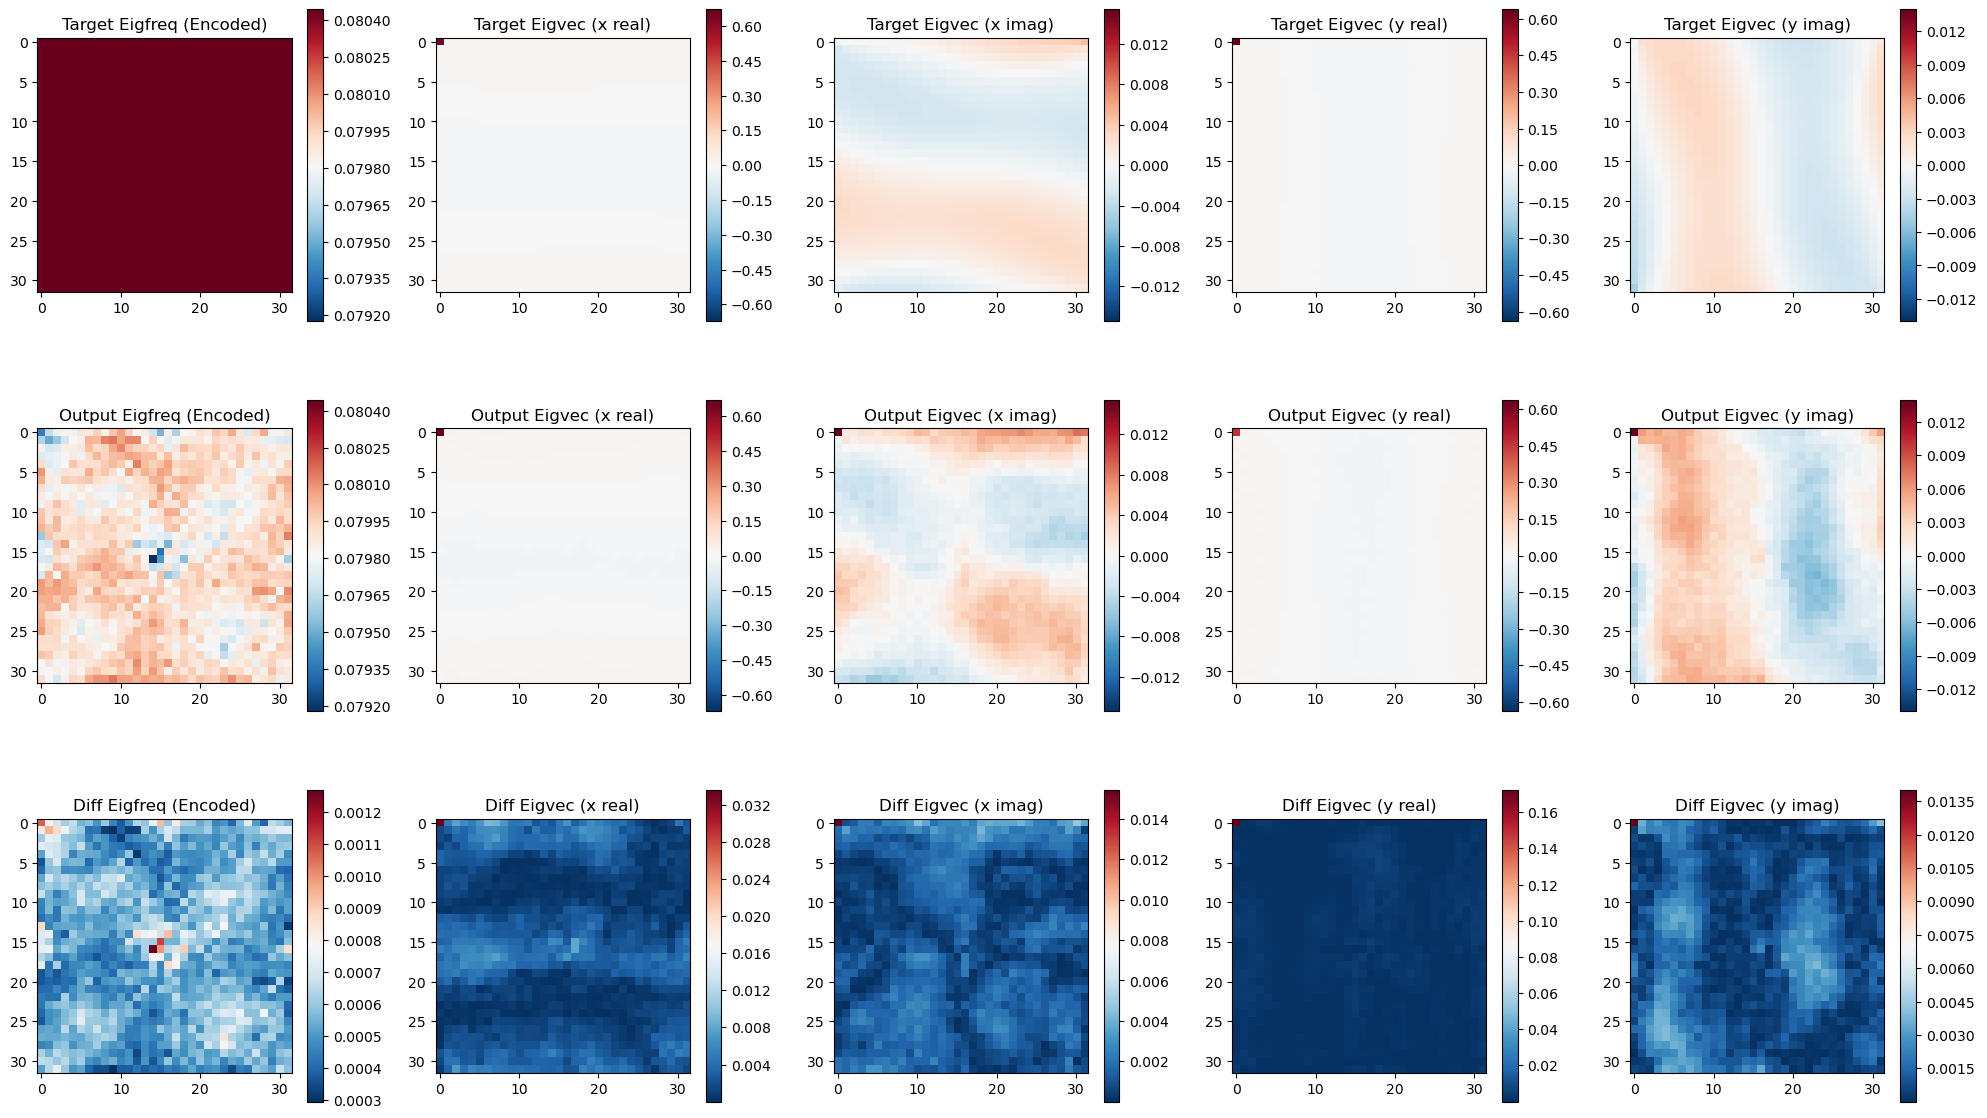

In [19]:
# Get a few random samples directly (no DataLoader needed)
num_samples = 5  # or however many you want
sample_seed = 10
sample_rng = torch.Generator().manual_seed(sample_seed)
# Preallocate lists for time efficiency
all_inputs = [None] * num_samples
all_predictions = [None] * num_samples
all_targets = [None] * num_samples

# Process each sample (c_test; switch to b_test_* for binary figures)
for i in range(num_samples):
    local_d = int(torch.randint(0, n, (1,), generator=sample_rng).item())
    geometry_idx = int(c_test_geom_idx[local_d])
    waveform_idx = int(torch.randint(0, c_test_n_wv, (1,), generator=sample_rng).item())
    band_idx = int(torch.randint(0, c_test_n_band, (1,), generator=sample_rng).item())

    geometry = c_test_geometries[local_d]
    waveform = c_test_waveforms[waveform_idx]
    band_fft = c_test_band_ffts[band_idx]
    target = c_test_stack_target_channels(geometry_idx, waveform_idx, band_idx)
    
    # Combine inputs
    input_tensor = torch.stack([geometry, waveform, band_fft], dim=0)  # [3, 32, 32]
    
    # Check sizes and data types
    print(f"Sample {i}: Input {input_tensor.shape} {input_tensor.dtype}, Target {target.shape} {target.dtype}")
    
    # Convert to float32 if needed to match model expectations
    if input_tensor.dtype != torch.float32:
        input_tensor = input_tensor.float()
    if target.dtype != torch.float32:
        target = target.float()
    
    # Move to device
    input_tensor = input_tensor.to(device)
    target = target.to(device)
    
    # Get prediction
    with torch.no_grad():
        prediction = model(input_tensor.unsqueeze(0)).squeeze(0)  # Add batch dim, then remove
    
    # Print max and min of input, output, and target
    print(f"Input max: {input_tensor.max():.4f}, min: {input_tensor.min():.4f}")
    print(f"Output max: {prediction.max():.4f}, min: {prediction.min():.4f}")
    print(f"Target max: {target.max():.4f}, min: {target.min():.4f}")
    print(f"Target scale (max - min): {target.max() - target.min():.4f}")
    # Compute average absolute error per pixel between output and target
    avg_abs_error = torch.mean(torch.abs(prediction - target)).item()
    print(f"Average absolute error per pixel (output vs target): {avg_abs_error:.6f}")
    
    # Visualize the sample (move tensors to CPU first)
    NO_utilities.visualize_sample(
        input_tensor.cpu(), 
        prediction.cpu(), 
        target.cpu(),
        unified_colorbar=False,
        field_cmap="RdBu_r",
        diverge_center=0.0
    )
    
    # Store for plotting (keep as 3x32x32 for inputs, 5x32x32 for predictions and targets)
    all_inputs[i] = input_tensor.cpu()  # [3, 32, 32]
    all_predictions[i] = prediction.cpu()  # [5, 32, 32]
    all_targets[i] = target.cpu()  # [5, 32, 32]


Visualizing sample 0 (index 136937)


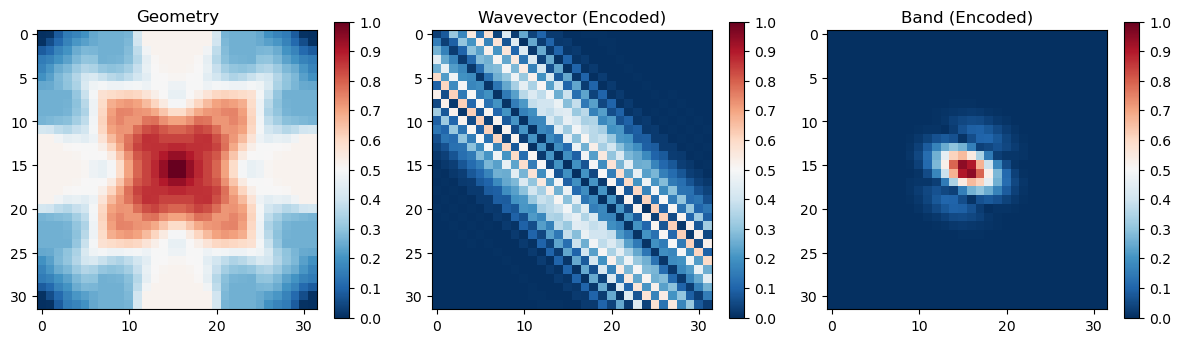

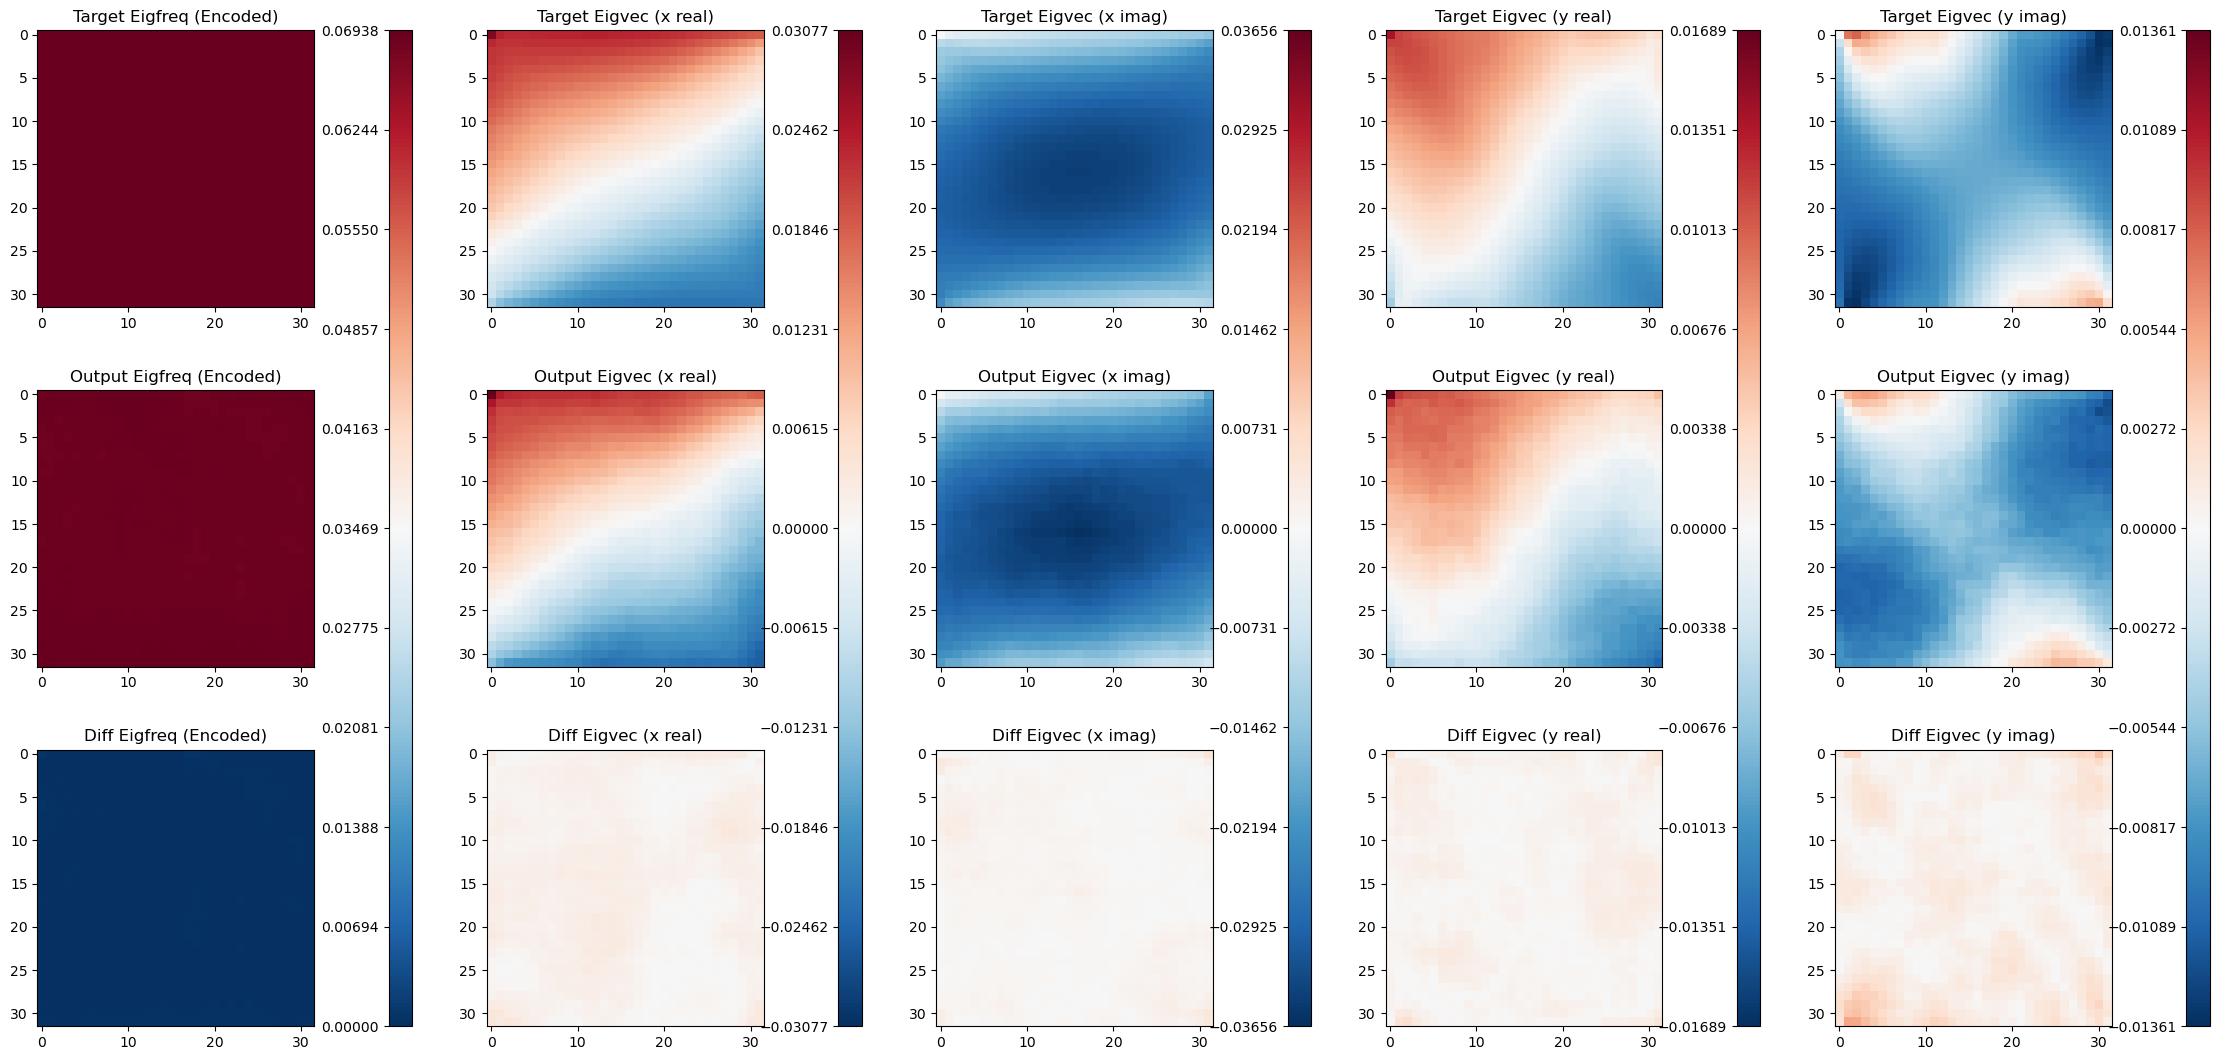

Visualizing sample 1 (index 72696)


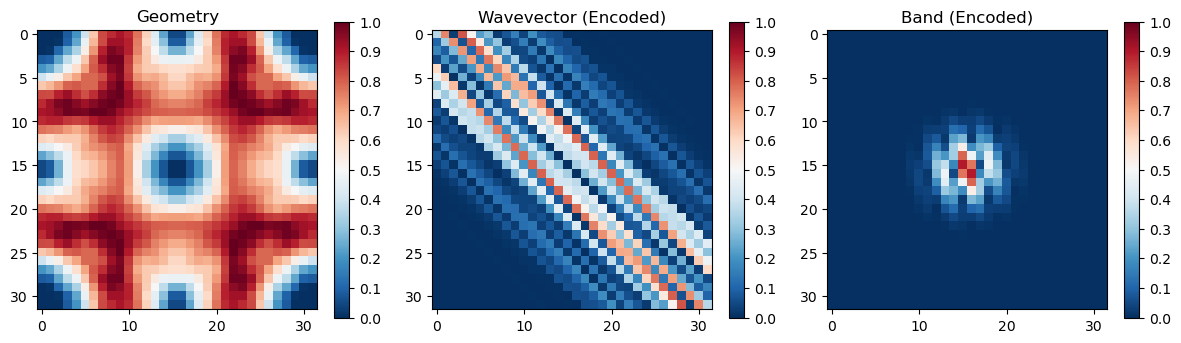

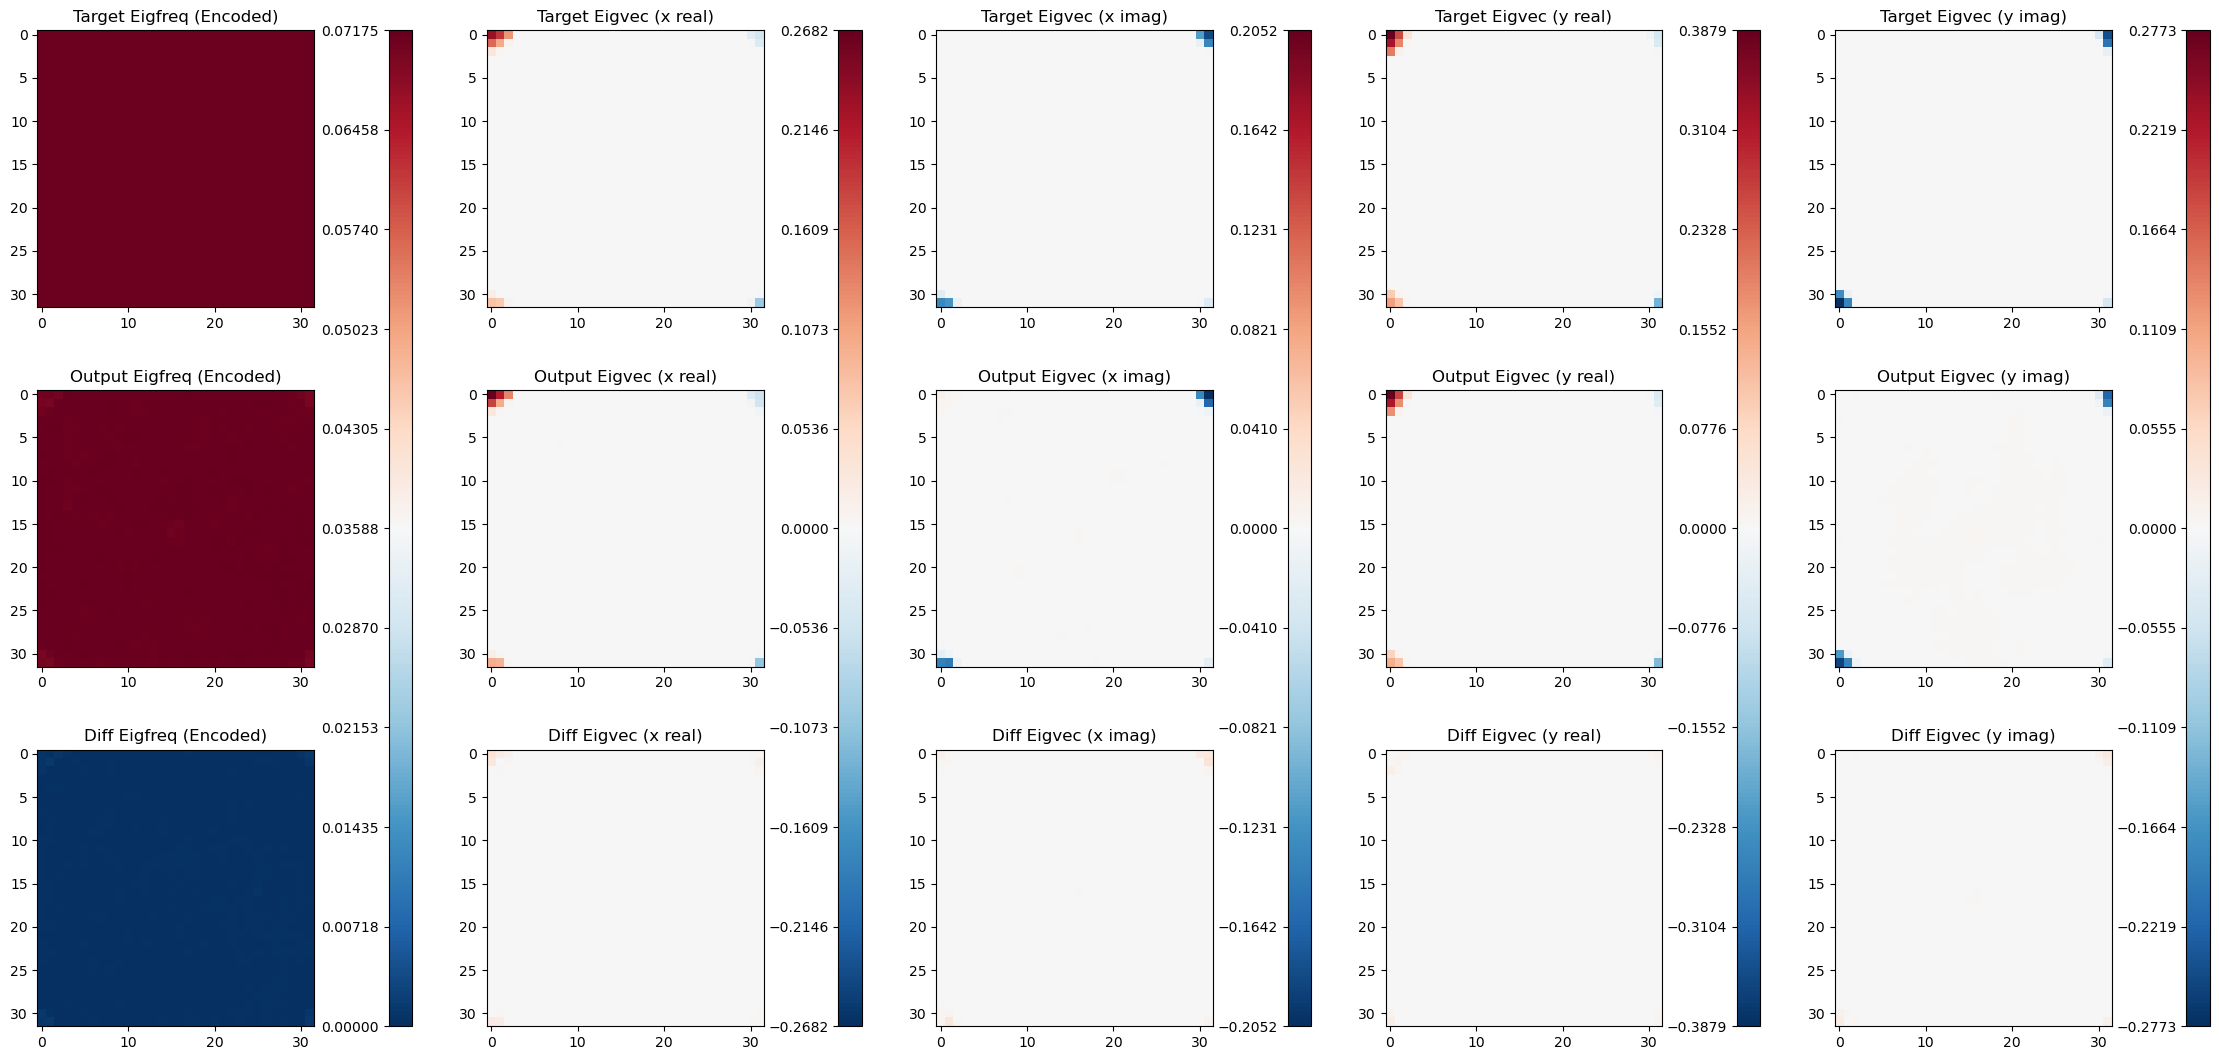

Visualizing sample 2 (index 209390)


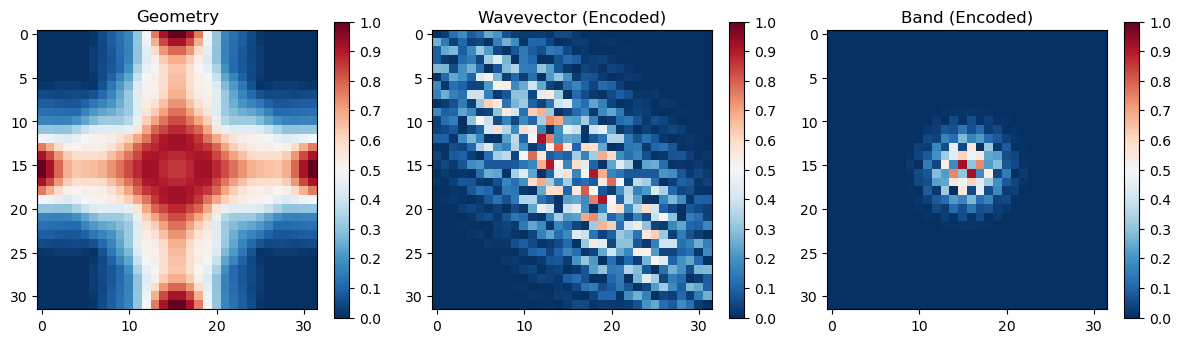

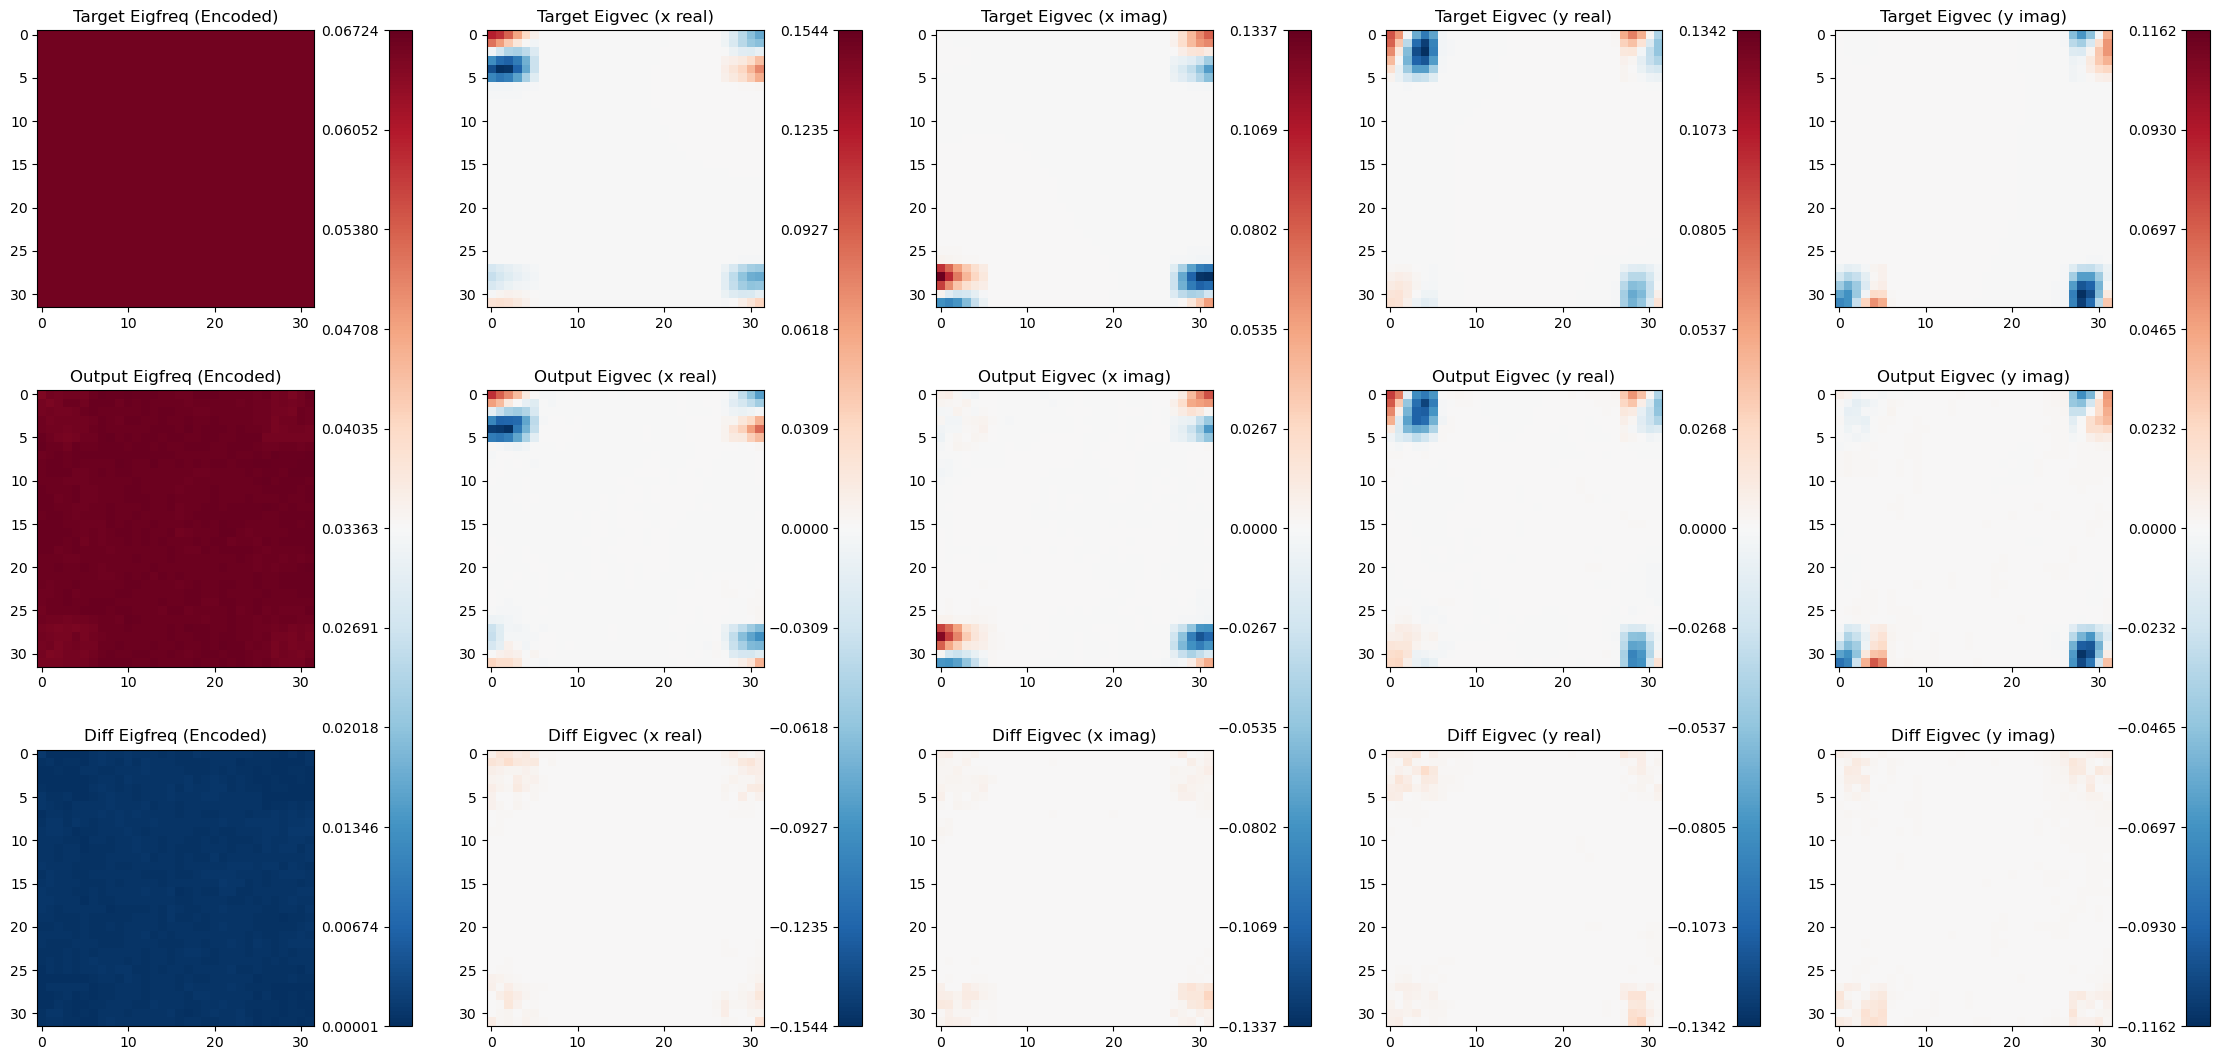

Visualizing sample 3 (index 323908)


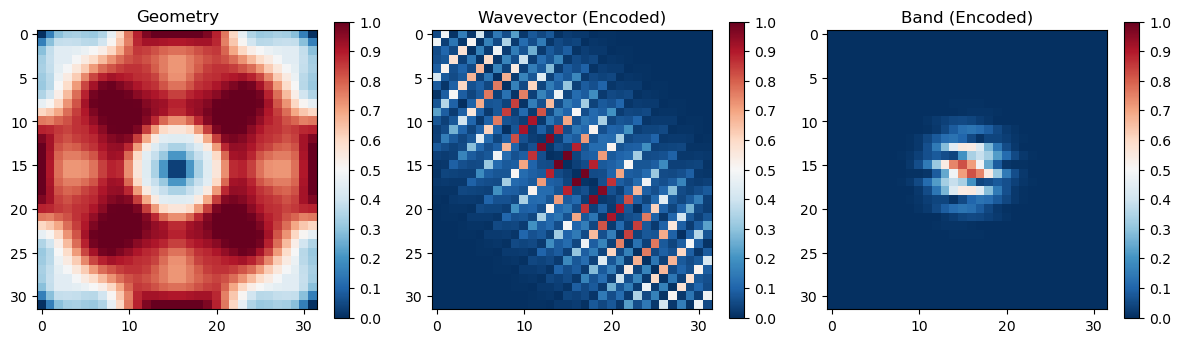

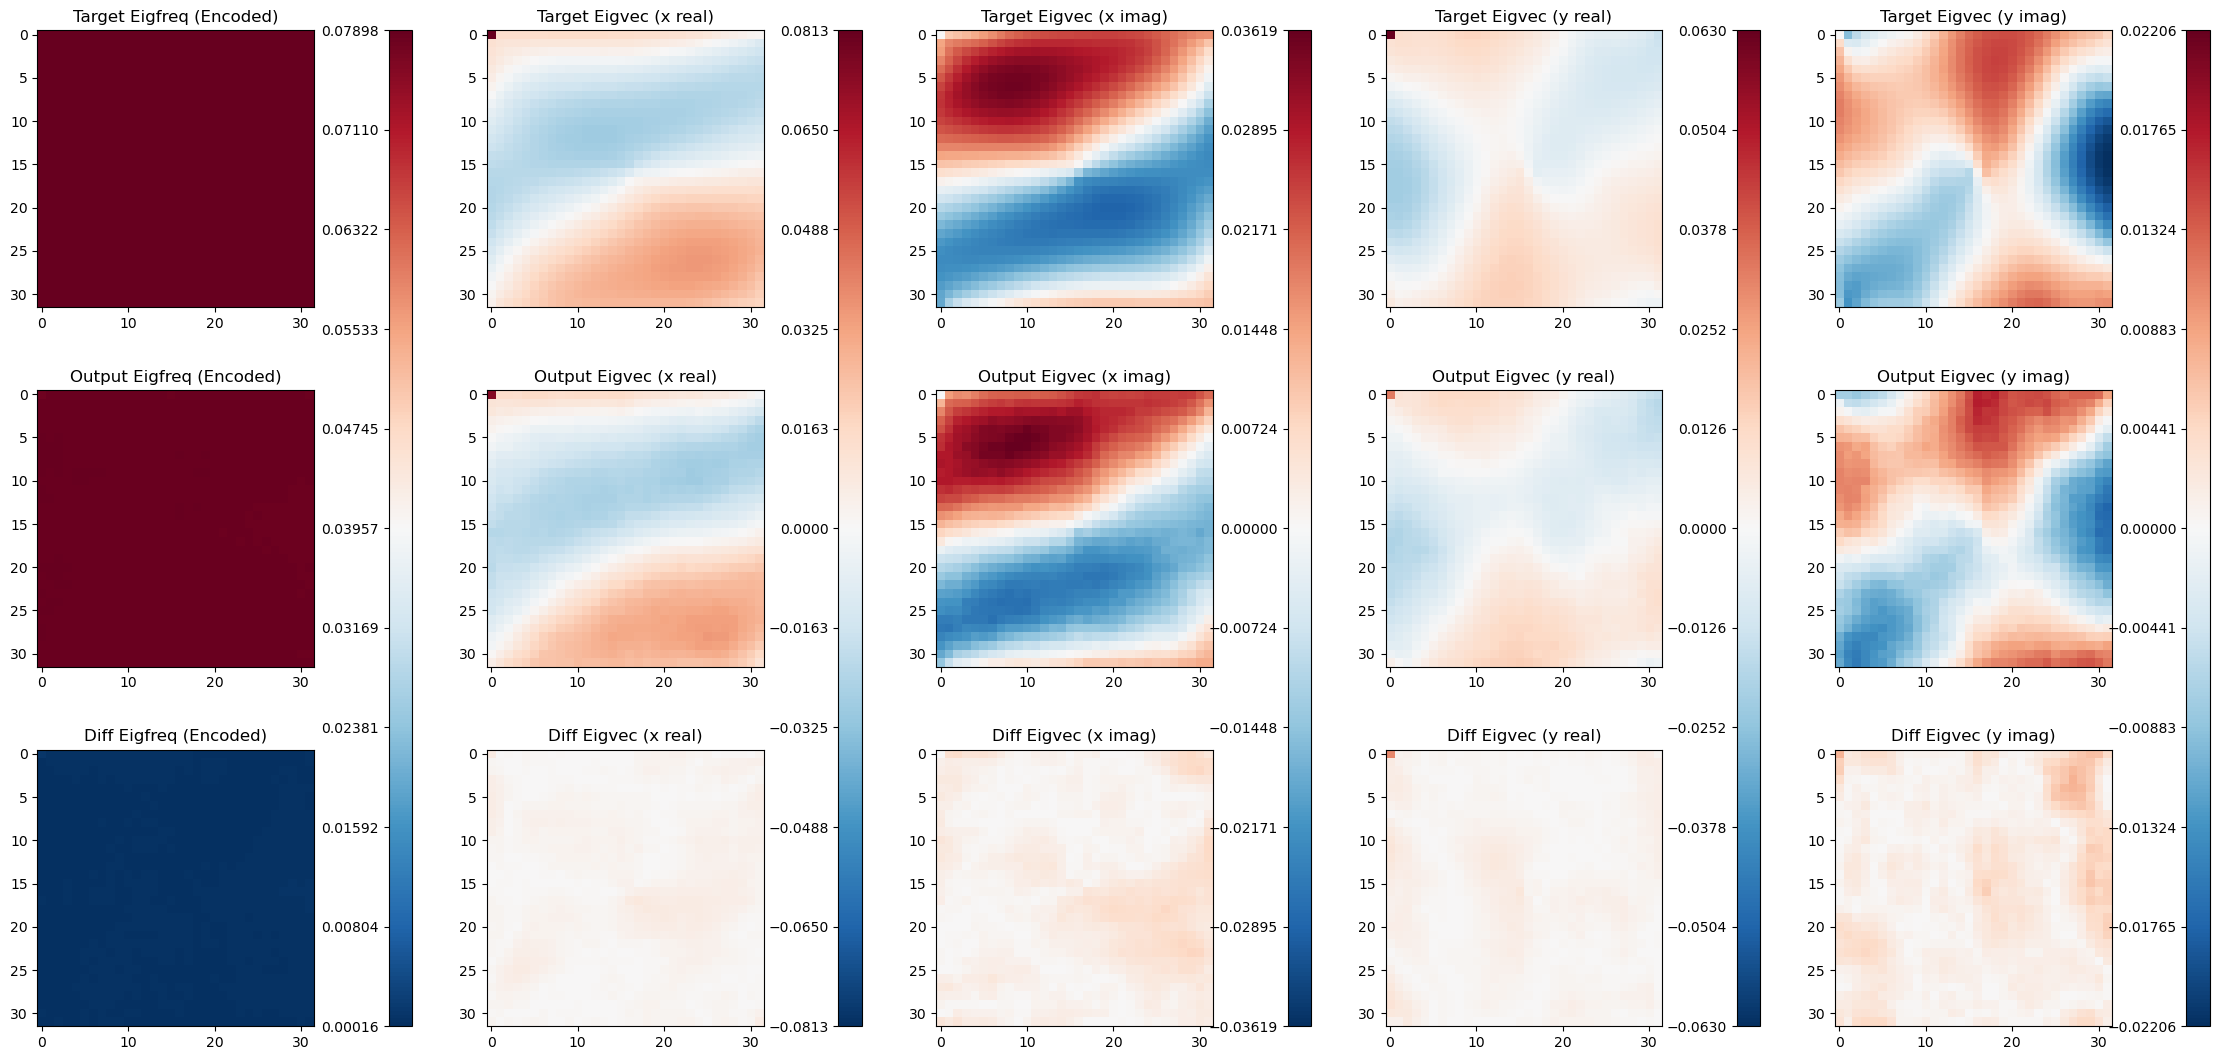

Visualizing sample 4 (index 106348)


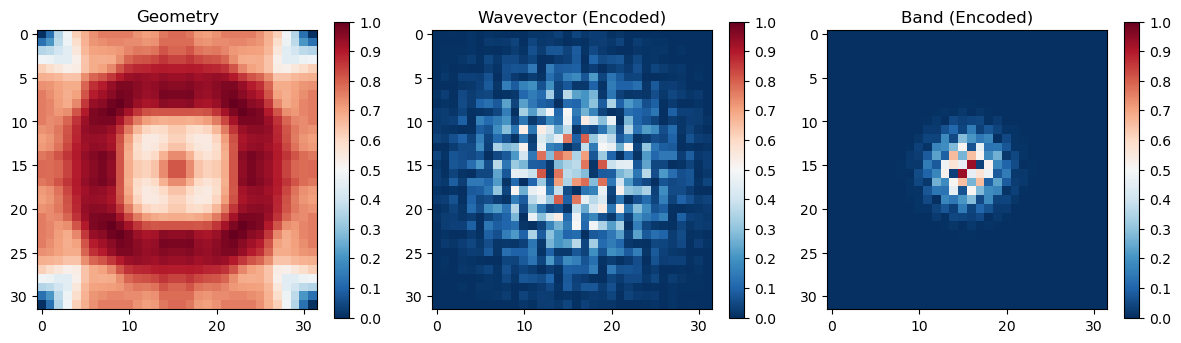

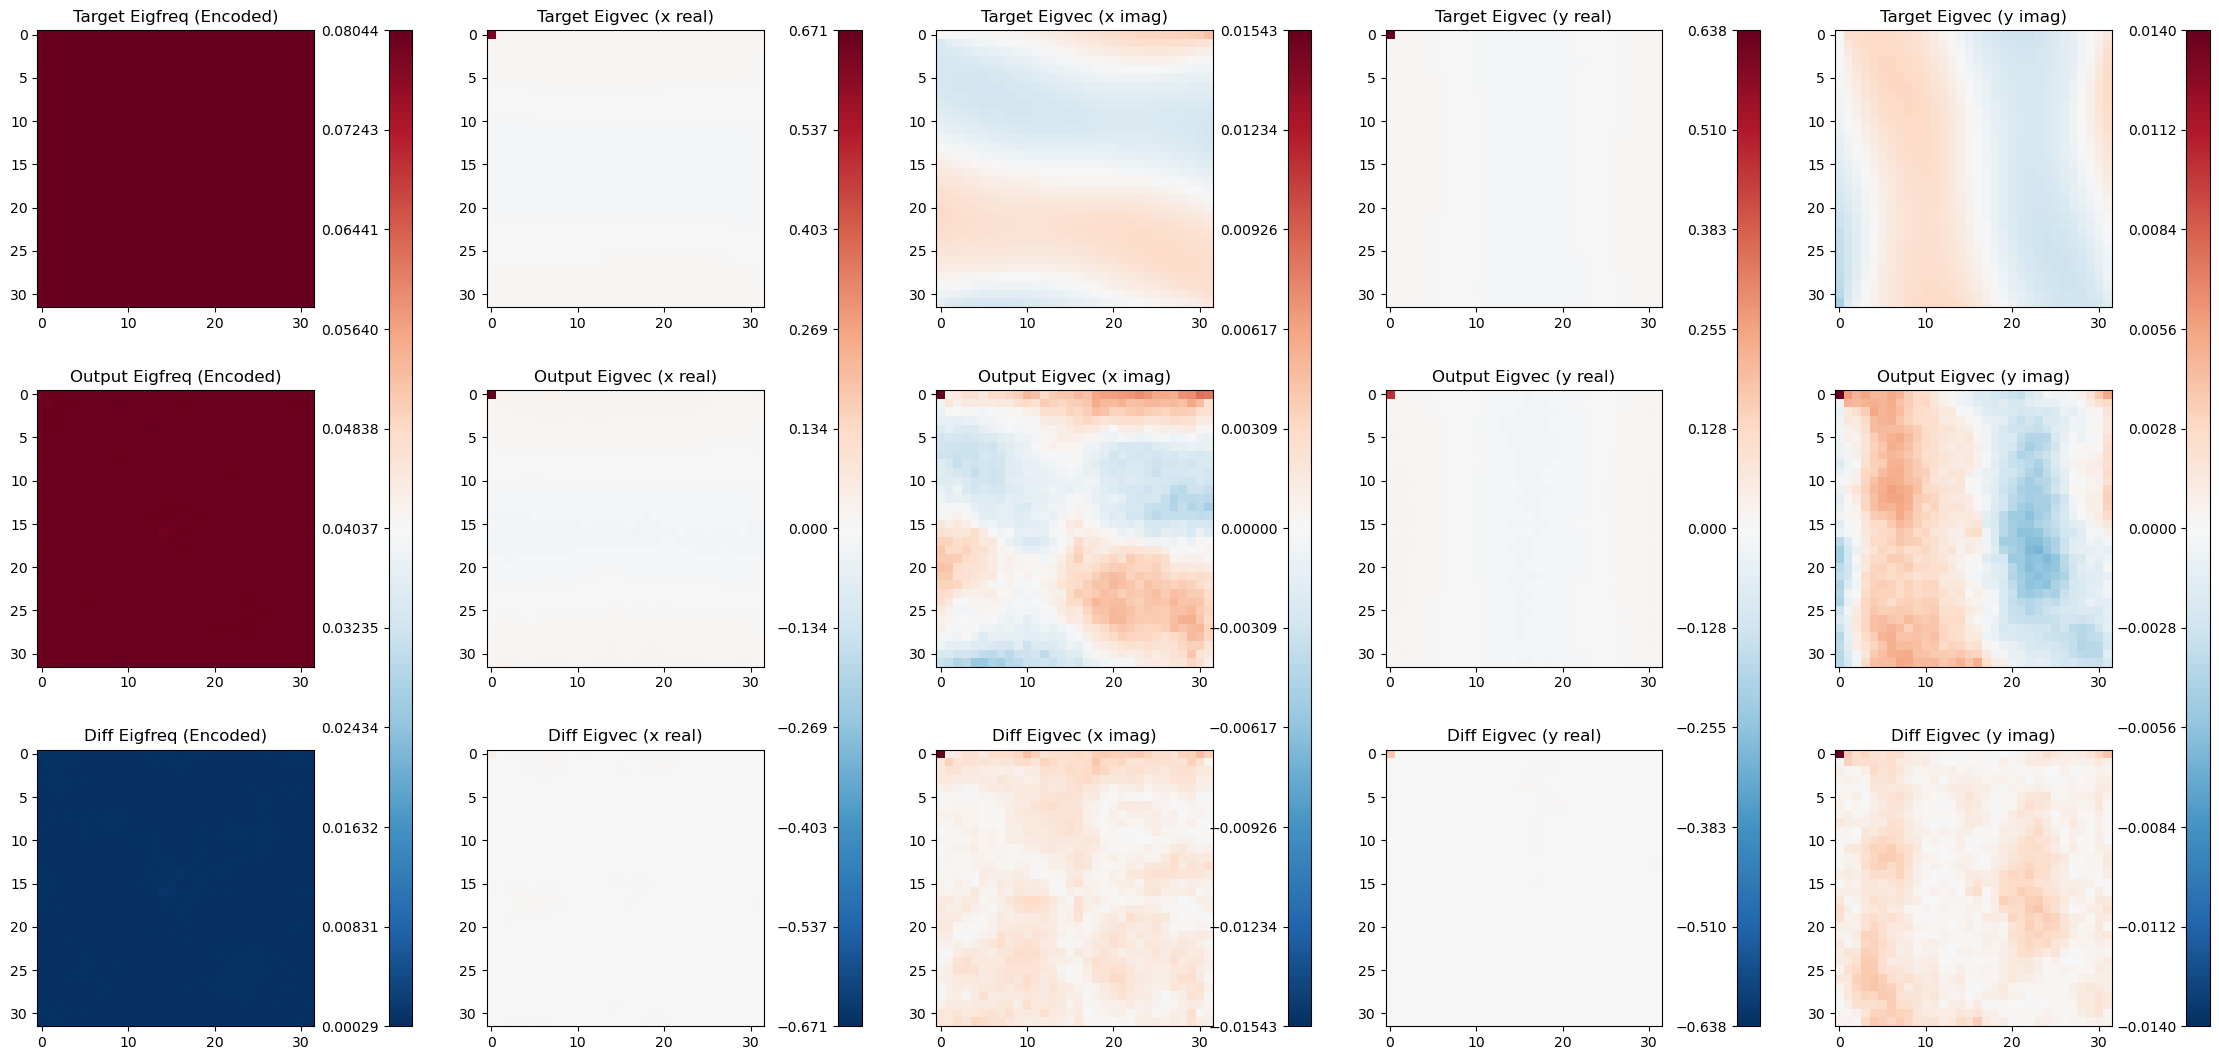

In [20]:
# Plots: NO_utilities.visualize_sample(..., unified_colorbar=True)
import importlib

importlib.reload(NO_utilities)

for i in range(num_samples):
    print(f"Visualizing sample {i}")

    input_sample = all_inputs[i]  # [3, 32, 32]
    output_sample = all_predictions[i]  # [C, 32, 32]
    target_sample = all_targets[i]  # [C, 32, 32]

    NO_utilities.visualize_sample(
        input_sample.cpu(),
        output_sample.cpu(),
        target_sample.cpu(),
        unified_colorbar=True,
        field_cmap="RdBu_r",
        diverge_center=0.0,
    )
